In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, r2_score
from itertools import product

# DS Marketing Case Study

### Objective
Use the Silver dataset to:
- assess data quality,
- transform the data into a Gold weekly dataset,
- measure channel impact with a marketing mix model,
- simulate spend changes, and
- recommend a better media allocation.

### How To Read This Notebook
1. Read the **Executive Summary** for the main answer in 2-3 minutes.
2. Skim sections **1-5** for data quality, Gold dataset construction, and reporting.
3. Jump to sections **7-9** for modeling, simulation, and optimization.

### Table of Contents
- 0 Setup and Assumptions
- 1 Exploratory Data Analysis
  - 1.1 Dataset Overview
  - 1.2 Episode Lifecycle Structure
  - 1.3 Missing Value Analysis
  - 1.4 Duplicate Detection
  - 1.5 Outlier Detection
- 2 Build Gold Weekly Dataset
- 3 Visualization and Correlation Analysis
  - 3.1 Categorical Distributions
  - 3.2 Continuous Distributions
  - 3.3 Scatter Relationships
  - 3.4 Correlation Heatmap
  - 3.5 Marketing Lifecycle Trends
- 4 Campaign-Level Reporting
- 5 Performance Metrics (CPM and ROAS)
- 6 Scenario Questions (Medallion Architecture)
- 7 Modeling (Marketing Mix Model)
- 8 Simulation
- 9 Optimization
- 10 Overall Conclusion


## Executive Summary

This notebook follows the case prompt from raw Silver data to business recommendation. The core task is to clean daily marketing records, roll them up to a weekly Gold dataset, and estimate which channels drive viewership most effectively.

### Cleaning Summary
- Started with **3,143 Silver-layer rows** across **8 shows** and **14 columns**.
- Found **157 rows** with at least one missing spend or outcome value. I imputed those values within the same episode-week when sibling rows contained the missing value.
- Found and removed **399 exact duplicate rows**.
- Aggregated daily records into a Gold dataset with **420 weekly observations**, one row per show-season-week-episode.

### Main Findings
- Marketing spend and impressions are very tightly related, so I exclude impressions from the MMM to avoid multicollinearity.
- Show-level efficiency differs materially: **Show8** has the strongest ROAS overall, while **Show1** and **Show3** are also consistently strong.
- The best-performing model is **Model 2 (adstock + saturation)** with **test R^2 = 0.9135** and **RMSE about 17,768 viewers**.
- Across all model variants, **Cable TV** is the strongest driver of viewership lift, followed by **Network TV**, with **Digital** still positive but weaker.
- A **+20% Digital spend** simulation adds about **266,816 predicted viewers** in the test period.
- Under a fixed budget, the best tested allocation is **40% Network TV / 60% Cable TV / 0% Digital**, which increases predicted revenue by about **$650K (+8.7%)** versus baseline.

### Modeling Choices
- I use **True_Viewership** as the MMM target because the case states that revenue is a fixed function of viewers.
- I include **Holiday** and **LeadIn_Bonus** as controls and add **show fixed effects** to absorb baseline popularity differences across titles.
- The notebook order mirrors the case prompt so each requested deliverable is easy to locate.


## 0. Setup and Assumptions


This section loads the Silver dataset and defines the working assumptions used throughout the case.

**Assumptions used in this notebook**
- Daily rows can be rolled up to a weekly episode grain for campaign reporting and MMM.
- Missing spend, revenue, and viewership values within the same episode-week reflect data gaps rather than true zeros.
- Revenue is proportional to viewership, so viewership is the cleaner modeling target and revenue is used later for business interpretation.


In [2]:
# =========================================================
# Load the Silver layer dataset
# =========================================================

# Read the CSV file into a pandas DataFrame.
df = pd.read_csv("Silver_Data.csv", index_col=0)

# Display the first 10 rows to inspect the structure of the dataset
df.head(10)

,Show,Season,Air_Date,Week_Number,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
0,Show2,1,2020-10-05,5,0,PreLaunch,"8,721.07","10,465.28","3,488.43",44768143,"66,845.59","45,352.47",0,0
1,Show4,3,2022-10-15,6,1,Premiere,"3,524.91",NaN,"8,812.28",38186541,"83,713.74","58,420.93",0,0
2,Show2,4,2023-10-27,8,3,Regular,"6,964.24","2,785.69","8,357.08",30178358,"63,736.23","45,484.81",0,0
3,Show7,1,2024-03-24,11,6,Regular,NaN,"7,625.93","6,354.94",27538068,"45,117.21","31,663.72",0,0
4,Show5,1,2023-08-14,10,5,Regular,"7,466.36","2,488.79","6,221.97",28621044,"87,525.73","60,840.97",0,0
5,Show8,1,2024-03-31,12,7,Regular,"3,002.17","7,505.43","9,006.52",31022458,"140,946.91","98,683.54",0,1
6,Show3,1,2020-10-07,5,0,PreLaunch,"15,944.83","19,133.80","6,377.93",81850153,"181,368.93","127,037.71",0,0
7,Show5,1,2023-09-03,13,8,Regular,"12,980.00","4,326.67","10,816.67",49756677,"85,371.40","60,393.52",1,0
8,Show2,5,2024-10-15,7,2,Regular,"8,916.04","2,972.01","7,430.03",34178154,"55,519.48","39,360.50",0,0
9,Show2,1,2020-12-17,15,10,Finale,"15,139.41","18,167.29","6,055.76",77715634,"92,831.00","67,108.41",0,0


## 1. Exploratory Data Analysis

### 1.1 Dataset Overview

In [3]:
# Check dataset shape (rows, columns) and data types
print("=== SHAPE ===")
print("rows:", df.shape[0])
print("cols:", df.shape[1])
print("\n=== DATA TYPES ===")
print(df.dtypes)

=== SHAPE ===
rows: 3143
cols: 14

=== DATA TYPES ===
Show                 object
Season                int64
Air_Date             object
Week_Number           int64
Episode_Number        int64
Episode_Type         object
Network_TV_Spend    float64
Cable_TV_Spend      float64
Digital_Spend       float64
Impressions           int64
True_Viewership     float64
Revenue             float64
Holiday               int64
LeadIn_Bonus          int64
dtype: object


In [4]:
# Changed data type of Air_Date to datetime
df["Air_Date"] = pd.to_datetime(df["Air_Date"], errors="coerce")

In [5]:
# Group the dataset by Show, then count how many UNIQUE seasons each show has
show_season_count = (
    df.groupby("Show")["Season"]
      .nunique()
      .reset_index(name="Season_Count")
      .sort_values("Show")
)

display(show_season_count)

,Show,Season_Count
0,Show1,5
1,Show2,5
2,Show3,5
3,Show4,5
4,Show5,2
5,Show6,2
6,Show7,2
7,Show8,2


In [6]:
# Group the dataset by Show and Season to examine how long each season runs
show_season_weeks = (
    df.groupby(["Show", "Season"])["Week_Number"]
      .max()
      .reset_index(name="Week_Max")
      .sort_values(["Show", "Season"])
)

display(show_season_weeks)

,Show,Season,Week_Max
0,Show1,1,15
1,Show1,2,15
2,Show1,3,15
3,Show1,4,15
4,Show1,5,15
5,Show2,1,15
6,Show2,2,15
7,Show2,3,15
8,Show2,4,15
9,Show2,5,15


In [7]:
# For each Show, compute the overall date range covered in the dataset
show_airdate_range = (
   df.groupby("Show")["Air_Date"]
    .agg(Earliest_Air_Date="min", Latest_Air_Date="max")
    .reset_index()
)

show_airdate_range

,Show,Earliest_Air_Date,Latest_Air_Date
0,Show1,2020-09-06,2024-12-14
1,Show2,2020-09-07,2024-12-15
2,Show3,2020-09-08,2024-12-16
3,Show4,2020-09-09,2024-12-17
4,Show5,2023-06-08,2024-09-18
5,Show6,2023-06-09,2024-09-19
6,Show7,2024-01-13,2025-04-25
7,Show8,2024-01-14,2025-04-26


**Dataset takeaway:** The Silver data covers 8 shows from September 2020 through April 2025. Shows 1-4 each have 5 seasons, Shows 5-8 each have 2 seasons, and every season follows a consistent 15-week lifecycle from prelaunch through finale.


### 1.2 Episode Lifecycle Structure

In [8]:

# 1) Collect unique weeks for each Show + Episode_Type
tmp = (
    df.groupby(["Show", "Episode_Type"])["Week_Number"]
    .apply(lambda x: sorted(x.dropna().unique().tolist()))
    .reset_index(name="Weeks")
)

# 2) Convert week list to readable string (e.g., 1–5, 6, 7–14)
def weeks_to_range_str(weeks):
    if not weeks:
        return ""
    weeks = sorted(weeks)
    if len(weeks) == 1:
        return str(weeks[0])
    if weeks == list(range(weeks[0], weeks[-1] + 1)):
        return f"{weeks[0]}–{weeks[-1]}"
    return ",".join(map(str, weeks))

tmp["Week_Range"] = tmp["Weeks"].apply(weeks_to_range_str)

# 3) Pivot to wide table 
show_stage_weeks = (
    tmp.pivot(index="Show", columns="Episode_Type", values="Week_Range")
    .reset_index()
)

# 4) Rename columns to desired names 
rename_map = {
    "Prelaunch": "Prelaunch_Weeks",
    "Premiere": "Premiere_Weeks",
    "Regular": "Regular_Weeks",
    "Finale": "Finale_Weeks" 
}
show_stage_weeks = show_stage_weeks.rename(columns=rename_map)

# 5) Reorder columns so Finale is last (safe even if some columns are missing)
desired_cols = ["Show", "Prelaunch_Weeks", "Premiere_Weeks", "Regular_Weeks", "Finale_Weeks"]
show_stage_weeks = show_stage_weeks.reindex(columns=desired_cols, fill_value="").sort_values("Show")

display(show_stage_weeks.style.hide(axis="index"))

Show,Prelaunch_Weeks,Premiere_Weeks,Regular_Weeks,Finale_Weeks
Show1,,6,7–14,15
Show2,,6,7–14,15
Show3,,6,7–14,15
Show4,,6,7–14,15
Show5,,6,7–14,15
Show6,,6,7–14,15
Show7,,6,7–14,15
Show8,,6,7–14,15


### 1.3 Missing Value Analysis

In [9]:
# Missing values (nulls) Summary 

print("\n=== MISSING VALUES ===")
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print(missing)


=== MISSING VALUES ===
                  missing_count  missing_pct
Digital_Spend                34         1.08
Revenue                      34         1.08
Network_TV_Spend             33         1.05
True_Viewership              32         1.02
Cable_TV_Spend               31         0.99
Show                          0         0.00
Season                        0         0.00
Air_Date                      0         0.00
Week_Number                   0         0.00
Episode_Number                0         0.00
Episode_Type                  0         0.00
Impressions                   0         0.00
Holiday                       0         0.00
LeadIn_Bonus                  0         0.00


In [10]:
# Extract all rows that contain at least one missing value (NA/NaN)
rows_with_any_na = df[df.isna().any(axis=1)].copy()
print("Rows with any NA:", rows_with_any_na.shape)

# Preview what the missing rows look like
display(rows_with_any_na.head(20))


Rows with any NA: (157, 14)


,Show,Season,Air_Date,Week_Number,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
1,Show4,3,2022-10-15,6,1,Premiere,"3,524.91",NaN,"8,812.28",38186541,"83,713.74","58,420.93",0,0
3,Show7,1,2024-03-24,11,6,Regular,NaN,"7,625.93","6,354.94",27538068,"45,117.21","31,663.72",0,0
28,Show8,1,2024-02-19,6,1,Premiere,NaN,"9,404.20","11,285.04",38870708,"141,823.09","99,835.90",0,0
41,Show8,2,2025-02-09,5,0,PreLaunch,"8,866.18","7,388.48",NaN,38420120,"134,500.27","93,648.73",0,0
62,Show3,3,2022-10-10,5,0,PreLaunch,"19,560.72",NaN,"23,472.86",84763109,"184,603.93",NaN,0,0
65,Show1,3,2022-11-27,13,8,Regular,"17,128.02",NaN,"14,273.35",65657415,"225,367.13","158,095.99",1,0
81,Show4,4,2023-10-04,5,0,PreLaunch,"11,054.36","9,211.97","3,684.79",47902223,NaN,"54,082.74",0,0
97,Show2,1,2020-11-01,8,3,Regular,NaN,NaN,"2,424.37",31112731,"69,982.93","50,137.18",0,0
149,Show6,1,2023-08-07,9,4,Regular,NaN,"24,412.63","8,137.54",104431802,"228,048.21","162,662.67",0,0
157,Show1,5,2024-11-18,12,7,Regular,NaN,"14,947.06","17,936.47",61781184,"211,957.81","148,636.64",0,0


In [11]:
# ----------------------------------------
# Impute missing values within SAME episode-week key (daily level)
# Assumption: within a given (Show, Season, Week_Number, Episode_Number, Episode_Type),
# metrics should be constant across days.
# Strategy: fill each missing cell using the first non-null value from other rows in the same group.
# ----------------------------------------

key_cols = ["Show", "Season", "Week_Number", "Episode_Number", "Episode_Type"]

# Put your “missing columns” here (edit names to exactly match your df columns)
fill_cols = [
    "Network_TV_Spend",
    "Cable_TV_Spend",
    "Digital_Spend",
    "Revenue",
    "True_Viewership"   
]

# Impute: within each key group, take the first non-null and broadcast to all rows
for c in fill_cols:
    if c not in df.columns:
        print(f"[skip] column not found: {c}")
        continue

    group_first_nonnull = df.groupby(key_cols)[c].transform(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
    df[c] = df[c].fillna(group_first_nonnull)

# Optional: quick check after imputation
post_missing = df[ [c for c in fill_cols if c in df.columns] ].isna().sum().sort_values(ascending=False)
print("Missing counts after group imputation:\n", post_missing)


Missing counts after group imputation:
 Network_TV_Spend    0
Cable_TV_Spend      0
Digital_Spend       0
Revenue             0
True_Viewership     0
dtype: int64


### 1.4 Duplicate Detection

In [12]:
# Check for exact duplicate rows
print("=== CHECK EXACT DUPLICATES ===")

# Identify rows that are exact duplicates across all columns
# - df.duplicated(keep=False) marks ALL rows that belong to a duplicate group
#   (instead of keeping the first one and marking only the rest)
duplicate_rows = df[df.duplicated(keep=False)]

# Print the total number of duplicate rows detected
print("Number of exact duplicate rows:", duplicate_rows.shape[0])

# Display a preview of duplicate rows
display(
    duplicate_rows
    .sort_values(["Show", "Season", "Week_Number","Air_Date", "Episode_Number"])
    .head(20)
)

=== CHECK EXACT DUPLICATES ===
Number of exact duplicate rows: 399


,Show,Season,Air_Date,Week_Number,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
391,Show1,2,2021-11-14,11,6,Regular,"21,439.92","7,146.64","17,866.60",82186350,"240,047.70","163,236.75",0,0
2437,Show1,2,2021-11-14,11,6,Regular,"21,439.92","7,146.64","17,866.60",82186350,"240,047.70","163,236.75",0,0
73,Show1,2,2021-11-15,11,6,Regular,"21,439.92","7,146.64","17,866.60",82186350,"240,047.70","163,236.75",0,0
827,Show1,2,2021-11-15,11,6,Regular,"21,439.92","7,146.64","17,866.60",82186350,"240,047.70","163,236.75",0,0
343,Show1,2,2021-11-16,11,6,Regular,"21,439.92","7,146.64","17,866.60",82186350,"240,047.70","163,236.75",0,0
426,Show1,2,2021-11-16,11,6,Regular,"21,439.92","7,146.64","17,866.60",82186350,"240,047.70","163,236.75",0,0
2015,Show1,2,2021-11-17,11,6,Regular,"21,439.92","7,146.64","17,866.60",82186350,"240,047.70","163,236.75",0,0
2748,Show1,2,2021-11-17,11,6,Regular,"21,439.92","7,146.64","17,866.60",82186350,"240,047.70","163,236.75",0,0
399,Show1,2,2021-11-18,11,6,Regular,"21,439.92","7,146.64","17,866.60",82186350,"240,047.70","163,236.75",0,0
892,Show1,2,2021-11-18,11,6,Regular,"21,439.92","7,146.64","17,866.60",82186350,"240,047.70","163,236.75",0,0


In [13]:
# Remove exact duplicate rows from the dataset
# - drop_duplicates() removes rows where all column values are identical
# - By default, it keeps the first occurrence and drops the rest
df = df.drop_duplicates().copy()

In [14]:
# Re-check for exact duplicate rows after removing duplicates
duplicate_rows = df[df.duplicated(keep=False)]
# rint the number of remaining duplicate rows in the dataset
print("Number of exact duplicate rows (after):", duplicate_rows.shape[0])

Number of exact duplicate rows (after): 0


### 1.5 Outlier Detection

In [15]:
def iqr_outlier_flags(s):
    """
    Flag outliers in a numeric Series using the 1.5*IQR rule.

    Steps:
    - Compute Q1 (25th percentile) and Q3 (75th percentile)
    - IQR = Q3 - Q1
    - Lower bound = Q1 - 1.5*IQR
    - Upper bound = Q3 + 1.5*IQR
    - Return a boolean mask where values outside [low, high] are flagged as outliers
    """
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (s < low) | (s > high)

# Loop through key numeric columns and report the outlier rate
for c in ["Network_TV_Spend","Cable_TV_Spend","Digital_Spend","Impressions","True_Viewership","Revenue"]:
    flags = iqr_outlier_flags(df[c].dropna())
    print(c, "outlier_rate:", round(flags.mean()*100, 2), "%")

Network_TV_Spend outlier_rate: 0.0 %
Cable_TV_Spend outlier_rate: 0.0 %
Digital_Spend outlier_rate: 0.0 %
Impressions outlier_rate: 0.0 %
True_Viewership outlier_rate: 0.0 %
Revenue outlier_rate: 0.0 %


### EDA Summary

- The overall structure is consistent once `Air_Date` is parsed to datetime.
- Missingness is light at roughly **1%** per spend or outcome field and can be repaired within the same episode-week.
- Exact duplicates are the biggest raw-data issue, with **399 duplicate rows** removed before aggregation.
- The IQR check does not flag meaningful numeric outliers, so I keep the remaining observations.


## 2. Build Gold Weekly Dataset

The target Gold layer has one row per `Show x Season x Week_Number x Episode_Number x Episode_Type`. This weekly grain is appropriate for campaign reporting, visualization, and MMM because spend, impressions, viewership, and revenue are all analyzed at the weekly episode level.


In [16]:
# Sort by Show, Season, Air_Date
df_sorted = (
    df.sort_values(by=["Show", "Season", "Air_Date"], ascending=[True, True, True])
      .reset_index(drop=True) 
)

df_sorted.head(50)

,Show,Season,Air_Date,Week_Number,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
0,Show1,1,2020-09-06,1,0,PreLaunch,"4,028.30","12,084.89","10,070.74",43639891,"117,856.38","82,590.01",0,0
1,Show1,1,2020-09-07,1,0,PreLaunch,"4,028.30","12,084.89","10,070.74",43639891,"117,856.38","82,590.01",0,0
2,Show1,1,2020-09-08,1,0,PreLaunch,"4,028.30","12,084.89","10,070.74",43639891,"117,856.38","82,590.01",0,0
3,Show1,1,2020-09-09,1,0,PreLaunch,"4,028.30","12,084.89","10,070.74",43639891,"117,856.38","82,590.01",0,0
4,Show1,1,2020-09-10,1,0,PreLaunch,"4,028.30","12,084.89","10,070.74",43639891,"117,856.38","82,590.01",0,0
5,Show1,1,2020-09-11,1,0,PreLaunch,"4,028.30","12,084.89","10,070.74",43639891,"117,856.38","82,590.01",0,0
6,Show1,1,2020-09-12,1,0,PreLaunch,"4,028.30","12,084.89","10,070.74",43639891,"117,856.38","82,590.01",0,0
7,Show1,1,2020-09-13,2,0,PreLaunch,"4,854.15","14,562.46","12,135.38",52586659,"129,214.06","88,792.03",0,0
8,Show1,1,2020-09-14,2,0,PreLaunch,"4,854.15","14,562.46","12,135.38",52586659,"129,214.06","88,792.03",0,0
9,Show1,1,2020-09-15,2,0,PreLaunch,"4,854.15","14,562.46","12,135.38",52586659,"129,214.06","88,792.03",0,0


In [17]:
# Aggregation: Build Gold weekly dataset 
weekly_df = (
    # Group by the episode-week key so each row represents a unique show-week episode
    df.groupby([
        "Show",
        "Season",
        "Week_Number",
        "Episode_Number",
        "Episode_Type"
    ], as_index=False)

    # Aggregate daily-level rows into a single weekly row per key
    .agg({
        # Use the earliest Air_Date as the week start date for the episode-week
        "Air_Date": "min",

        # Use "first" for fields assumed constant within the same episode-week group.
        "Network_TV_Spend": "first",
        "Cable_TV_Spend": "first",
        "Digital_Spend": "first",
        "Impressions": "first",
        "True_Viewership": "first",
        "Revenue": "first",

        # Control variables assumed constant within a week/episode group
        "Holiday": "first",
        "LeadIn_Bonus": "first"
    })
)

weekly_df.head(25)

,Show,Season,Week_Number,Episode_Number,Episode_Type,Air_Date,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
0,Show1,1,1,0,PreLaunch,2020-09-06,"4,028.30","12,084.89","10,070.74",43639891,"117,856.38","82,590.01",0,0
1,Show1,1,2,0,PreLaunch,2020-09-13,"4,854.15","14,562.46","12,135.38",52586659,"129,214.06","88,792.03",0,0
2,Show1,1,3,0,PreLaunch,2020-09-20,"5,370.45","16,111.36","13,426.13",58179911,"171,609.76","121,836.52",0,0
3,Show1,1,4,0,PreLaunch,2020-09-27,"7,619.32","22,857.97","19,048.30",82542651,"178,971.84","124,396.60",0,0
4,Show1,1,5,0,PreLaunch,2020-10-04,"7,133.22","21,399.65","17,833.04",77276510,"192,167.78","131,526.19",0,0
5,Show1,1,6,1,Premiere,2020-10-11,"7,026.08","21,078.25","17,565.21",76115914,"200,169.24","139,261.51",0,0
6,Show1,1,7,2,Regular,2020-10-18,"9,276.47","27,829.40","23,191.17",100495060,"222,394.06","159,013.44",0,0
7,Show1,1,8,3,Regular,2020-10-25,"7,524.99","22,574.97","18,812.48",81520738,"221,726.57","157,093.77",0,0
8,Show1,1,9,4,Regular,2020-11-01,"8,125.42","24,376.27","20,313.56",88025405,"224,137.09","156,114.50",0,0
9,Show1,1,10,5,Regular,2020-11-08,"5,907.18","17,721.54","14,767.95",63994463,"213,068.37","148,403.70",0,0


## 3. Data Visualization & Correlation Analysis

This section uses descriptive plots to answer two practical questions before modeling: which shows and campaigns look materially different, and which variables are likely to be redundant or informative in the MMM.


### 3.1 Categorical Distributions

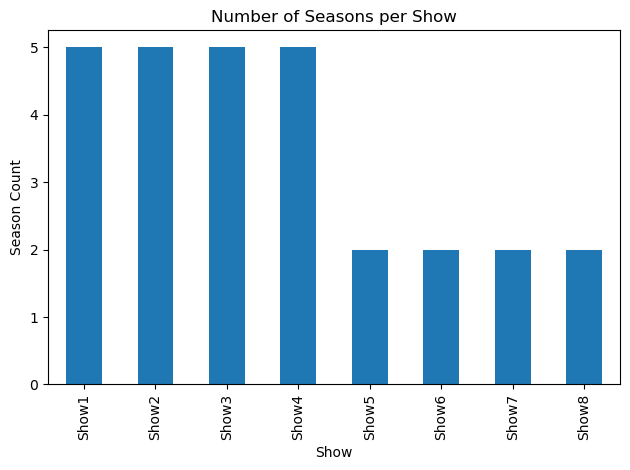

In [18]:
# Plot: Number of Seasons per Show (using weekly_df)

# For each show, count how many unique seasons appear in the weekly dataset.

show_season_count = (
    weekly_df.groupby("Show")["Season"]
    .nunique()         # count distinct Season values per Show
    .sort_index()      # sort by Show name for a cleaner bar chart order
)

# Create a bar chart to visualize how many seasons are available per show
ax = show_season_count.plot(kind="bar", title="Number of Seasons per Show")

# Label axes 
ax.set_xlabel("Show")
ax.set_ylabel("Season Count")

plt.tight_layout()
plt.show()

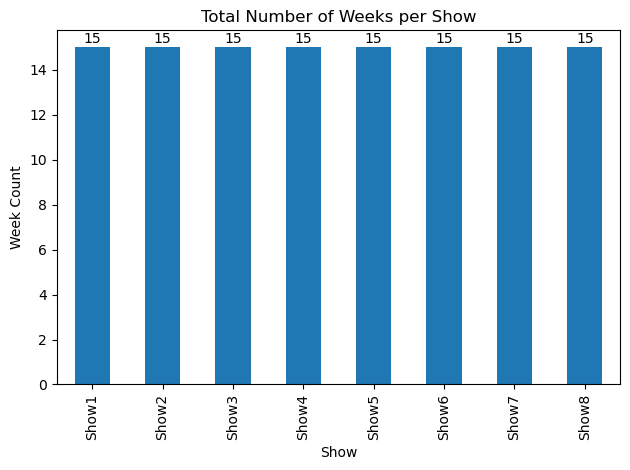

In [19]:
# Plot: Total Number of Weeks per Show

# For each show, count how many unique weeks appear in the dataset.
show_week_count = (
    weekly_df.groupby("Show")["Week_Number"]
    .nunique()          # count distinct Week_Number values per Show
    .sort_index()       # sort shows alphabetically for consistent plotting
)

# Create a bar chart to visualize the total number of weeks per show
ax = show_week_count.plot(kind="bar", title="Total Number of Weeks per Show")

# Label axes 
ax.set_xlabel("Show")
ax.set_ylabel("Week Count")

# Add the numeric value above each bar
for i, v in enumerate(show_week_count):
    ax.text(i, v + 0.2, str(v), ha="center")
    
plt.tight_layout()
plt.show()

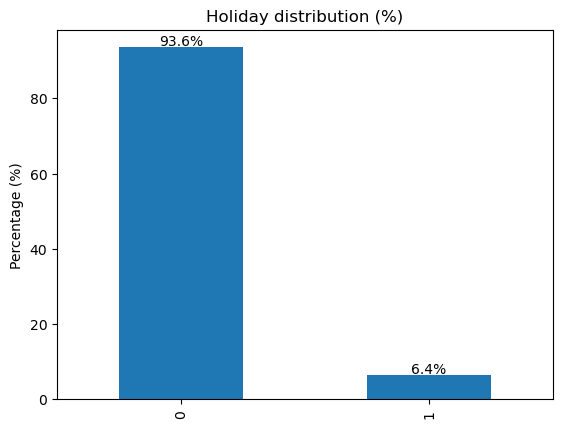

In [20]:
# Plot: Holiday distribution (percentage)

# 1) Compute the percentage share of Holiday = 0 vs Holiday = 1
pct = weekly_df["Holiday"].value_counts(normalize=True).sort_index() * 100

# 2) Create a bar chart
ax = pct.plot(kind="bar", title="Holiday distribution (%)")

# Label the y-axis
ax.set_ylabel("Percentage (%)")

# 3) Add percentage labels
for i, v in enumerate(pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.show()

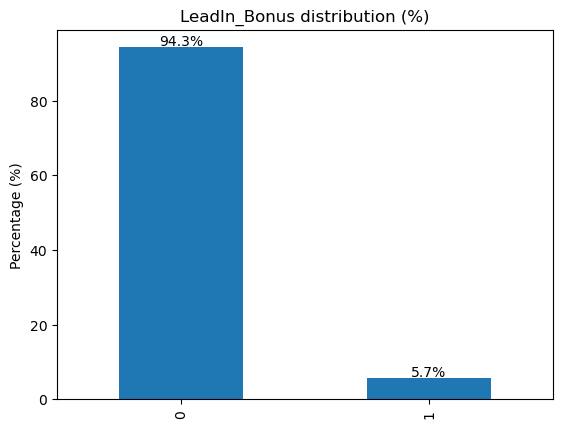

In [21]:
# Plot: LeadIn_Bonus distribution (percentage)

# 1) Compute the percentage share of LeadIn_Bonus = 0 vs LeadIn_Bonus = 1
pct = weekly_df["LeadIn_Bonus"].value_counts(normalize=True).sort_index() * 100

# 2) Create a bar chart
ax = pct.plot(kind="bar", title="LeadIn_Bonus distribution (%)")

# Label the y-axis
ax.set_ylabel("Percentage (%)")

# 3) Add percentage labels above each bar
for i, v in enumerate(pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.show()

### 3.2 Continuous Variable Distributions

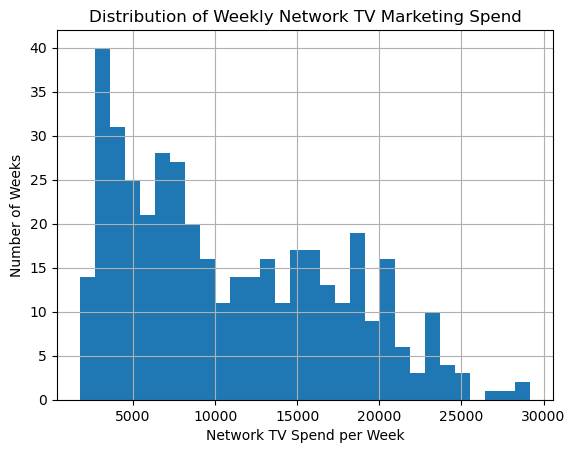

In [22]:
# Plot a histogram of Network TV marketing spend

weekly_df["Network_TV_Spend"].hist(bins=30)

# Add axis labels and title
plt.xlabel("Network TV Spend per Week")
plt.ylabel("Number of Weeks")
plt.title("Distribution of Weekly Network TV Marketing Spend")

plt.show()

In [23]:
# Calculate the skewness of the Network_TV_Spend distribution
# - skew() measures how asymmetric the distribution is
# - Positive skew (>0): right-skewed (long tail on the right, a few very large spends)
# - Negative skew (<0): left-skewed (long tail on the left)
# - Near 0: approximately symmetric distribution
weekly_df["Network_TV_Spend"].skew()

0.5321280336061909

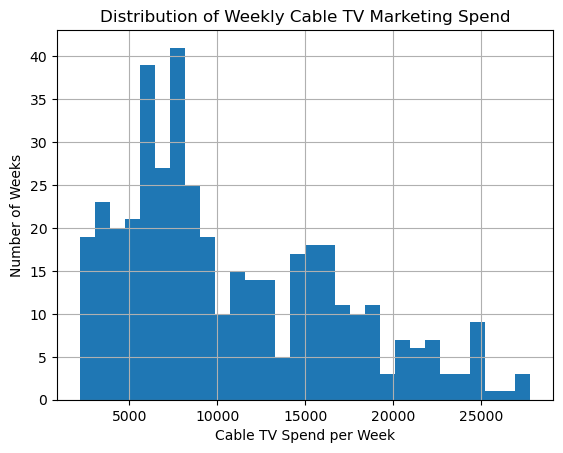

In [24]:
# Plot a histogram of Cable_TV marketing spend
weekly_df["Cable_TV_Spend"].hist(bins=30)

# Add axis labels and title
plt.xlabel("Cable TV Spend per Week")
plt.ylabel("Number of Weeks")
plt.title("Distribution of Weekly Cable TV Marketing Spend")

plt.show()

In [25]:
# Calculate the skewness of the Cable_TV_Spend distribution
weekly_df["Cable_TV_Spend"].skew() # moderately right-skewed

0.735184669740181

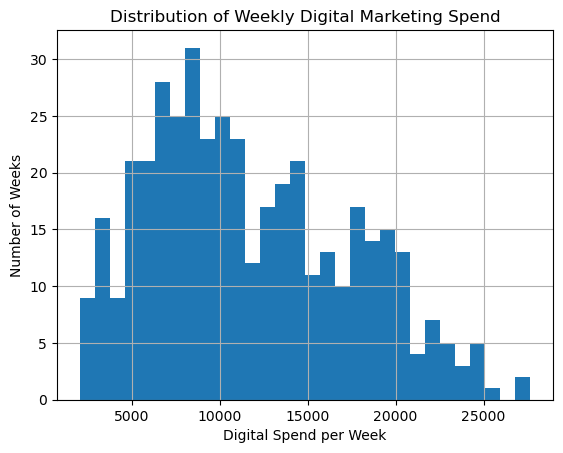

In [26]:
# Plot a histogram of Digital marketing spend

weekly_df["Digital_Spend"].hist(bins=30)

# Add axis labels and title
plt.xlabel("Digital Spend per Week")
plt.ylabel("Number of Weeks")
plt.title("Distribution of Weekly Digital Marketing Spend")

plt.show()

In [27]:
# Calculate the skewness of the Digital_Spend distribution
weekly_df["Digital_Spend"].skew() # moderately right-skewed

0.46038087442447134

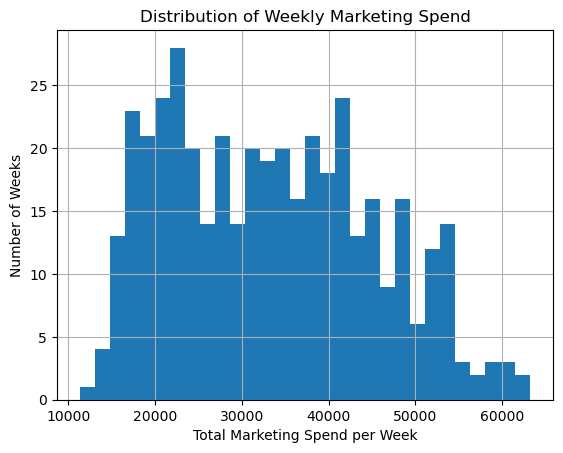

In [28]:
# =========================================================
# Distribution of weekly total marketing spend
# =========================================================

# 1) Create a Total_Spend column by summing spend across all three channels
# This represents the total marketing budget spent for a show-week (episode-week).
weekly_df["Total_Spend"] = (
    weekly_df["Network_TV_Spend"]
    + weekly_df["Cable_TV_Spend"]
    + weekly_df["Digital_Spend"]
)

# 2) Plot a histogram to visualize how Total_Spend is distributed across weeks
weekly_df["Total_Spend"].hist(bins=30)

# 3) Add axis labels and title 
plt.xlabel("Total Marketing Spend per Week")
plt.ylabel("Number of Weeks")
plt.title("Distribution of Weekly Marketing Spend")

plt.show()

In [29]:
# Calculate the skewness of the Total Spend distribution
weekly_df["Total_Spend"].skew() 

0.3006195084732182

In [30]:
# Total Spend Statistic Summary 
weekly_df["Total_Spend"].describe()

count      420.00
mean    33,378.36
std     11,850.73
min     11,296.74
25%     22,898.86
50%     32,940.05
75%     41,839.43
max     63,270.48
Name: Total_Spend, dtype: float64

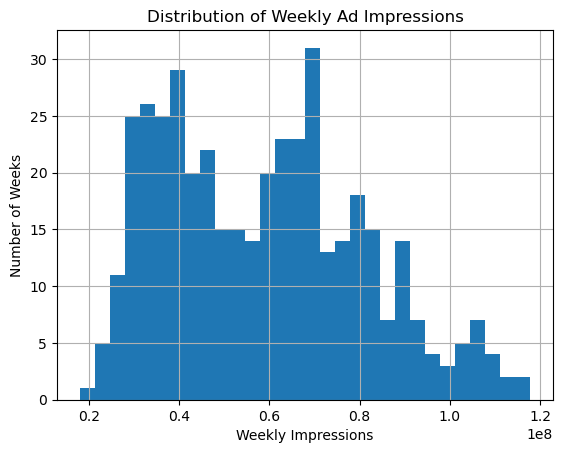

In [31]:
# Distribution of weekly Impressions
weekly_df["Impressions"].hist(bins=30)

# Label axes and title
plt.xlabel("Weekly Impressions")
plt.ylabel("Number of Weeks")
plt.title("Distribution of Weekly Ad Impressions")

plt.show()

In [32]:
# Calculate the skewness of the Impressions distribution
weekly_df["Impressions"].skew() 

0.42258060306077594

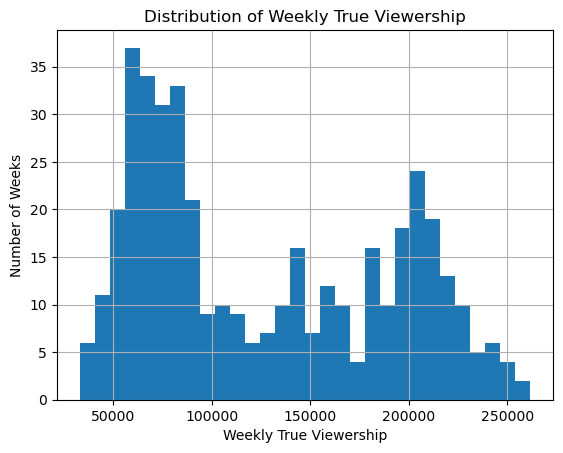

In [33]:
# Distribution of weekly True Viewership

weekly_df["True_Viewership"].hist(bins=30)

# Label axes and add title
plt.xlabel("Weekly True Viewership")
plt.ylabel("Number of Weeks")
plt.title("Distribution of Weekly True Viewership")

plt.show()

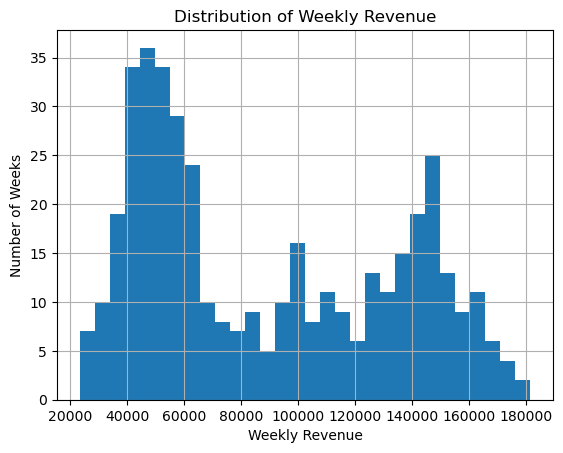

In [34]:
# Distribution of weekly revenue

weekly_df["Revenue"].hist(bins=30)

# Add axis labels and title 
plt.xlabel("Weekly Revenue")
plt.ylabel("Number of Weeks")
plt.title("Distribution of Weekly Revenue")

plt.show()

### 3.3 Scatter Relationships

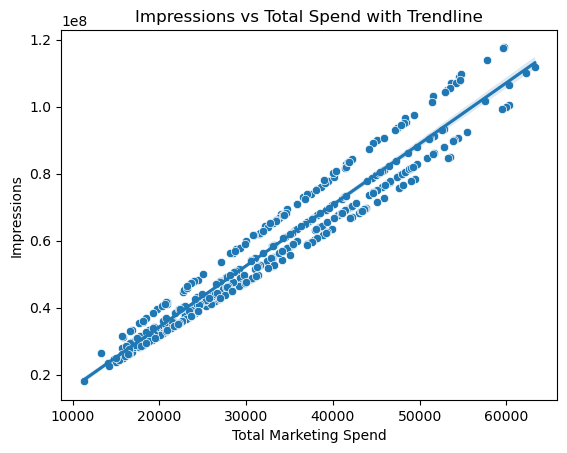

In [35]:
# Scatter plot: Total marketing spend vs. Impressions
# - Each point represents one weekly observation (episode-week)
# - Helps visualize whether higher spend generally corresponds to more impressions
sns.scatterplot(
    data=weekly_df,
    x="Total_Spend",
    y="Impressions"
)

# Add a regression trendline (without plotting the points again)
# - scatter=False ensures only the fitted line is drawn
# - This provides a quick visual sense of the overall linear relationship
sns.regplot(
    data=weekly_df,
    x="Total_Spend",
    y="Impressions",
    scatter=False
)

# Add labels and title
plt.xlabel("Total Marketing Spend")
plt.ylabel("Impressions")
plt.title("Impressions vs Total Spend with Trendline")

plt.show()

**Interpretation:** Total spend and impressions are close to linear because impressions are generated by paid media. I therefore avoid putting both spend and impressions into the MMM at the same time, since impressions would mostly act as a spend proxy and introduce unnecessary multicollinearity.


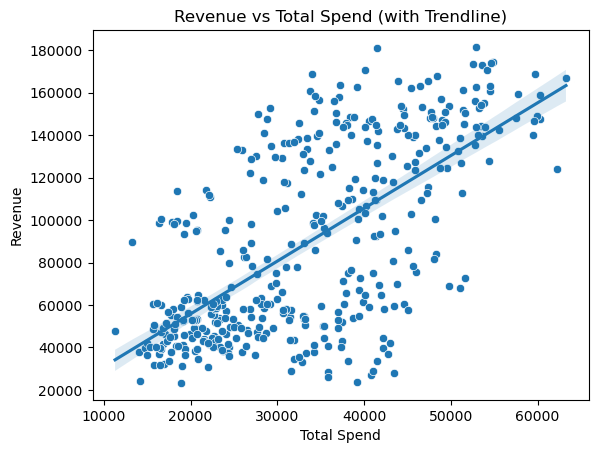

In [36]:
# Scatter plot: Total marketing spend vs Revenue
sns.scatterplot(data=weekly_df, x="Total_Spend", y="Revenue")

# Add a regression trendline on top of the scatter plot
sns.regplot(
    data=weekly_df,
    x="Total_Spend",
    y="Revenue",
    scatter=False
)

# Add axis labels and titley
plt.xlabel("Total Spend")
plt.ylabel("Revenue")
plt.title("Revenue vs Total Spend (with Trendline)")

plt.show()

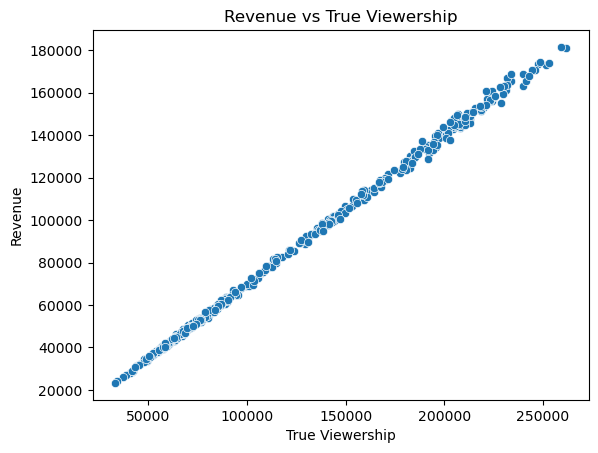

In [37]:
# Scatter plot: True Viewership vs Revenue

# Since revenue is often driven by viewership (e.g., advertising revenue),
# we expect to see a positive relationship between these two variables

sns.scatterplot(
    data=weekly_df,
    x="True_Viewership",
    y="Revenue"
)

# Add axis labels and title
plt.xlabel("True Viewership")
plt.ylabel("Revenue")
plt.title("Revenue vs True Viewership")

plt.show()

### 3.4 Correlation Heatmap

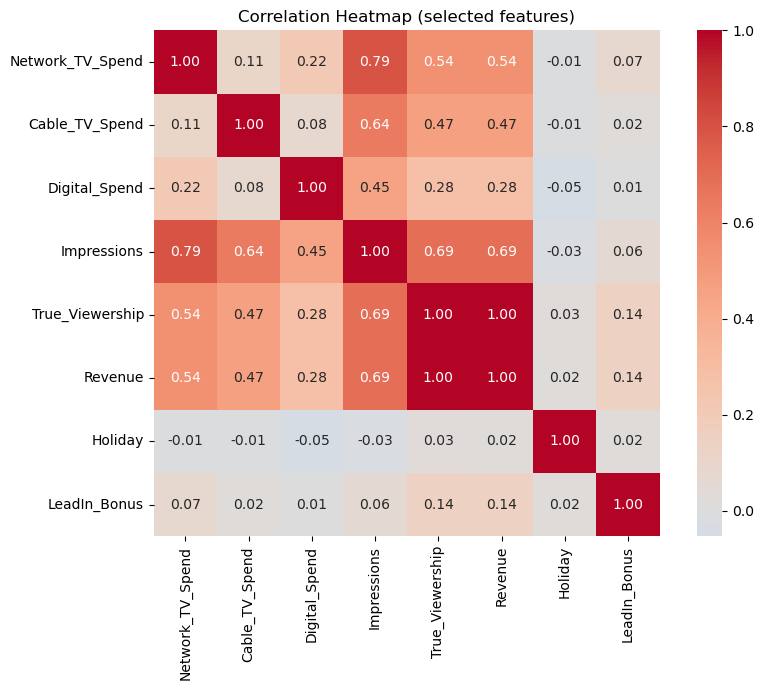

In [38]:
# Correlation heatmap for selected features

# Select the numeric columns we want to examine in the correlation matrix
cols = [
    "Network_TV_Spend",
    "Cable_TV_Spend",
    "Digital_Spend",
    "Impressions",
    "True_Viewership",
    "Revenue",
    "Holiday",
    "LeadIn_Bonus"
]

# Keep only columns that actually exist in weekly_df to avoid KeyError
cols = [c for c in cols if c in weekly_df.columns]

# Compute the correlation matrix (Pearson correlation by default)
# - Values range from -1 (strong negative) to +1 (strong positive)
corr = weekly_df[cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(9, 7))

# Heatmap settings:
# - annot=True: show correlation values in each cell
# - fmt=".2f": format values to 2 decimals
# - center=0: center the color scale at 0 (neutral correlation)
# - square=True: make each cell square for cleaner layout
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)

# Add a title and adjust layout so labels are not cut off
plt.title("Correlation Heatmap (selected features)")
plt.tight_layout()

### 3.5 Marketing Lifecycle Trends

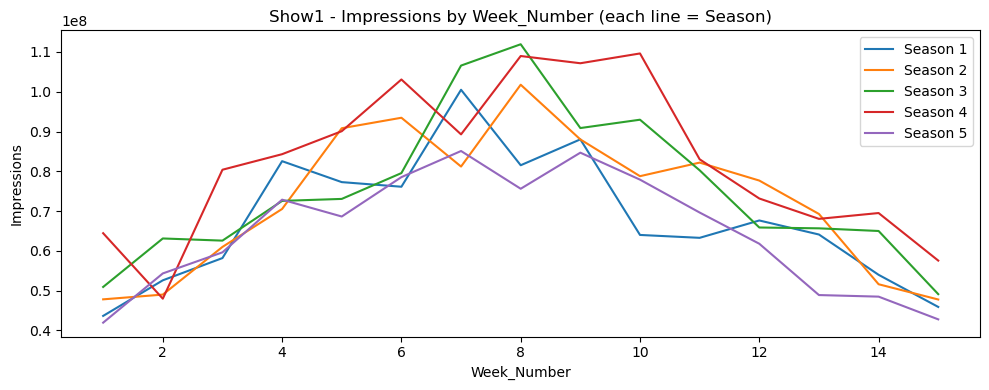

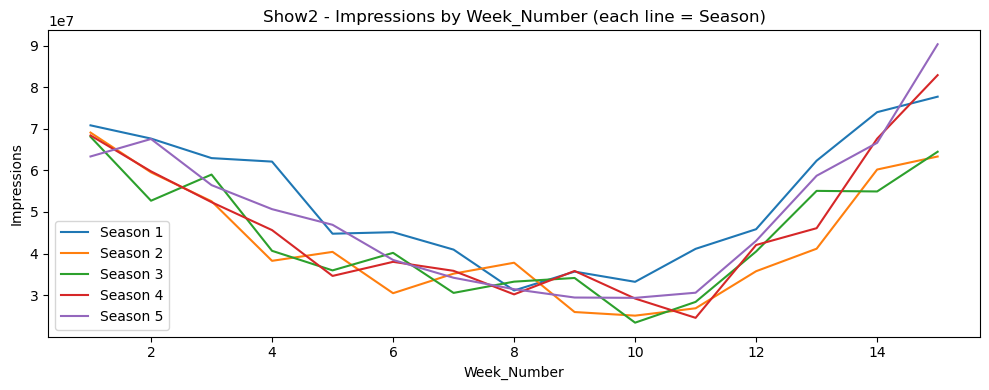

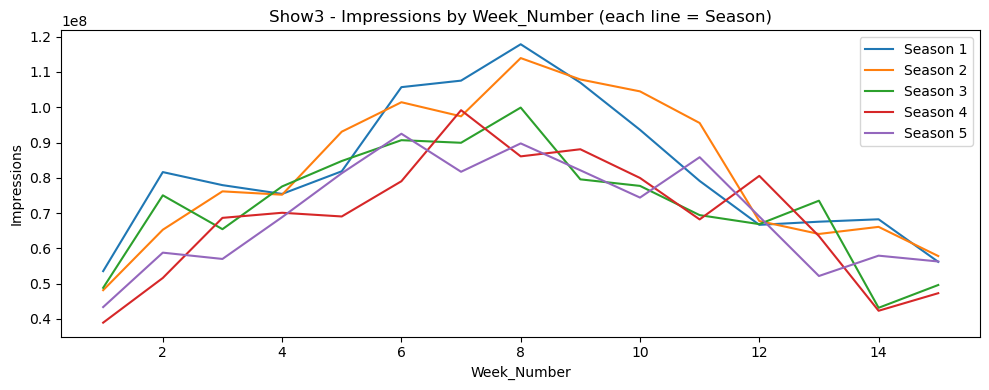

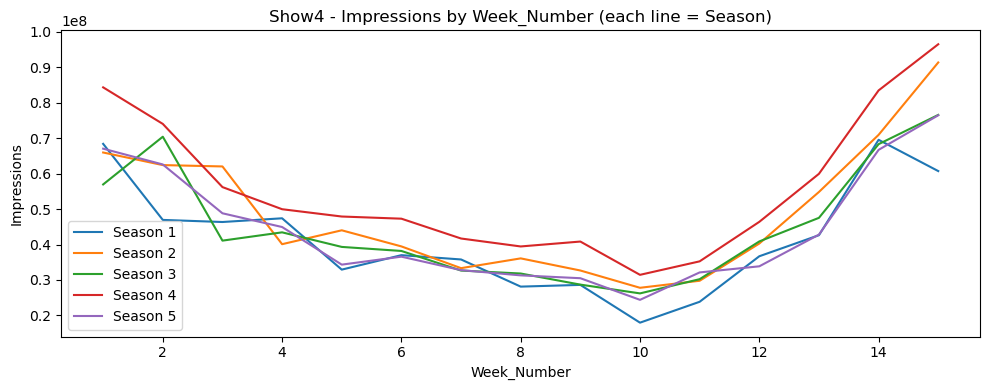

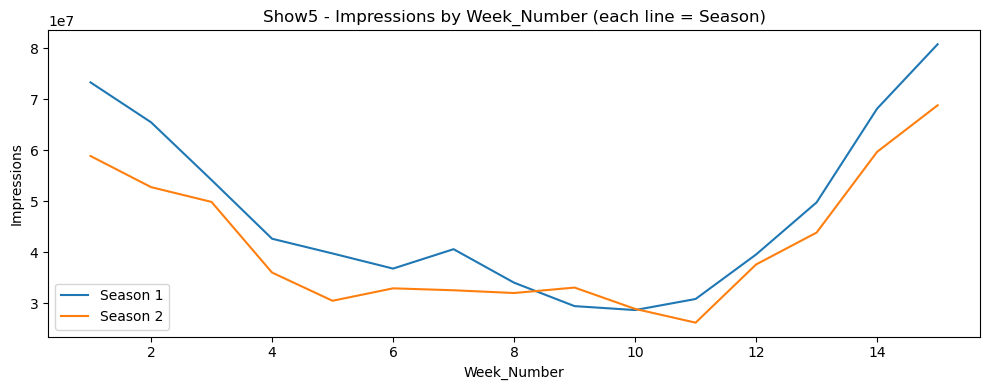

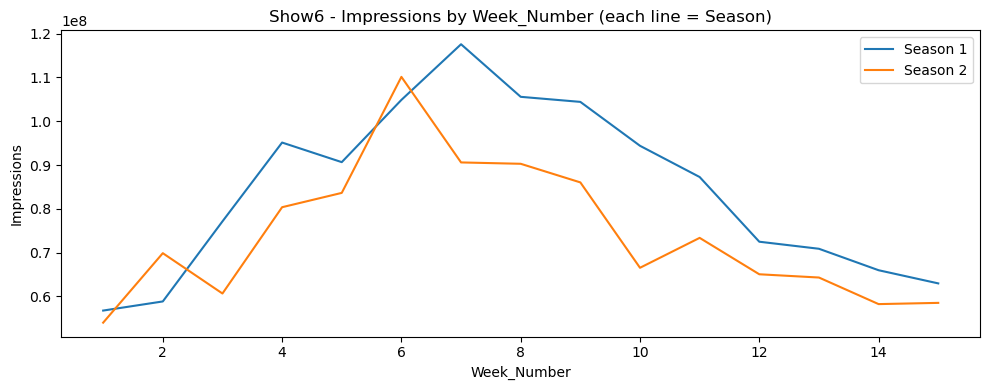

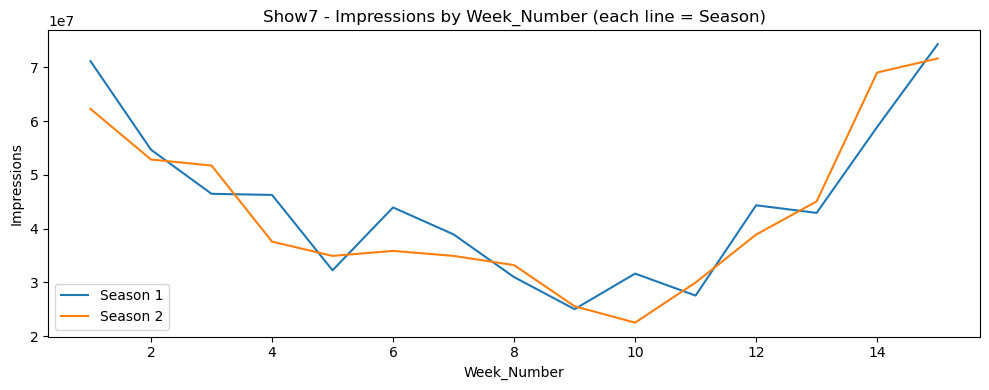

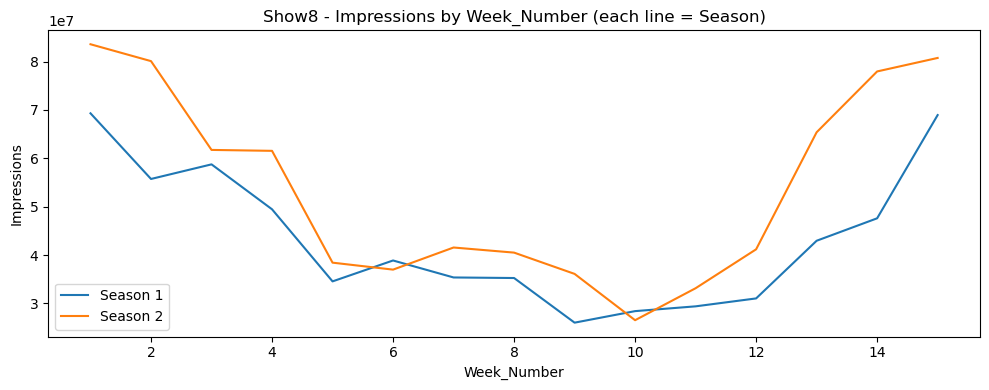

In [39]:
# Impression by week
# Loop through each show (iterate over unique show names in sorted order)
for show in sorted(weekly_df["Show"].unique()):

    # Filter weekly_df to only include rows for the current show
    tmp = weekly_df[weekly_df["Show"] == show]

    # Get all seasons available for this show (sorted for consistent plotting)
    seasons = sorted(tmp["Season"].unique())

    # Create a new figure for this show
    plt.figure(figsize=(10, 4))

    # Plot one line per season to compare season-level impression patterns
    for s in seasons:
        # Filter to the current season and sort by Week_Number so the line is chronological
        s_df = tmp[tmp["Season"] == s].sort_values("Week_Number")

        # Plot impressions over weeks for this season
        plt.plot(s_df["Week_Number"], s_df["Impressions"], label=f"Season {s}")

    # Add title and axis labels
    # Each line corresponds to one season for the same show
    plt.title(f"{show} - Impressions by Week_Number (each line = Season)")
    plt.xlabel("Week_Number")
    plt.ylabel("Impressions")

    # Show the legend so we can distinguish seasons
    plt.legend()

    # Adjust layout to prevent labels/titles from being cut off
    plt.tight_layout()

    plt.show()

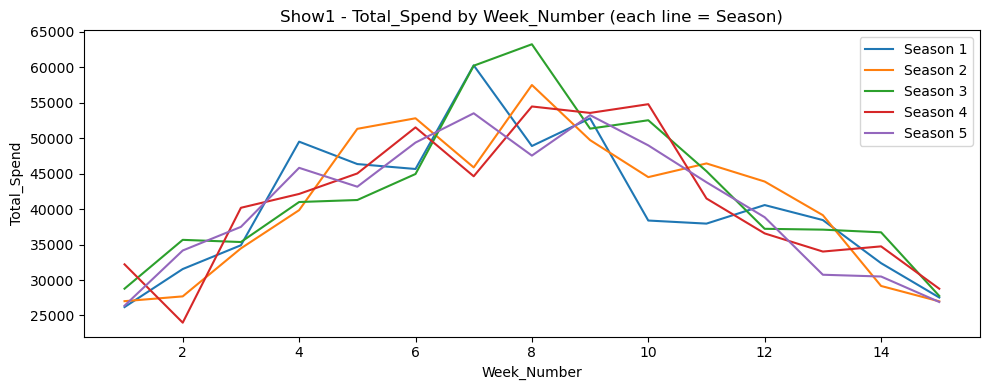

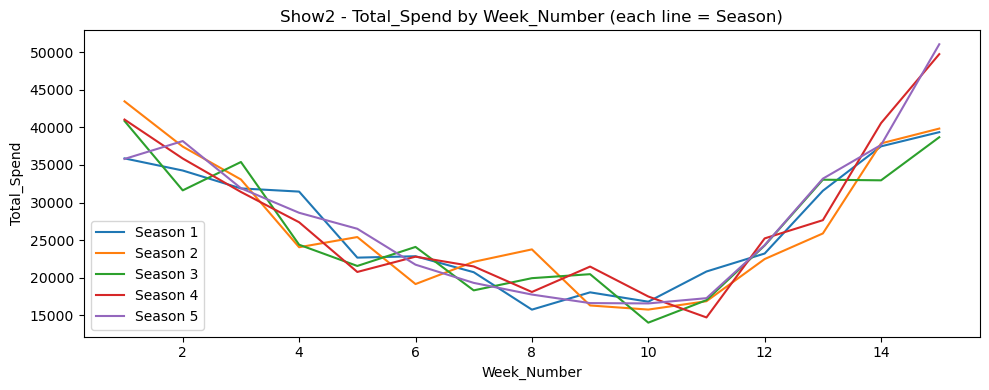

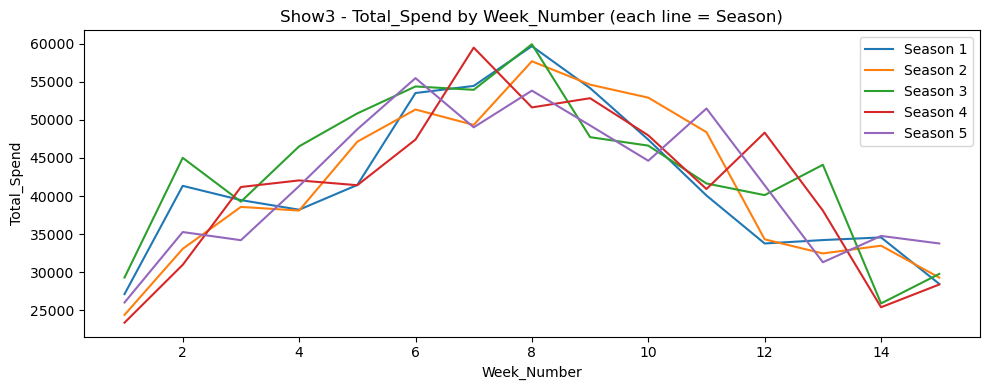

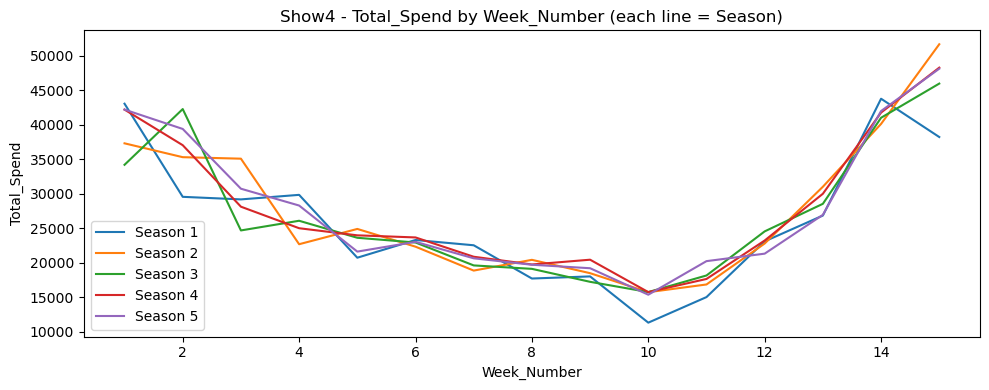

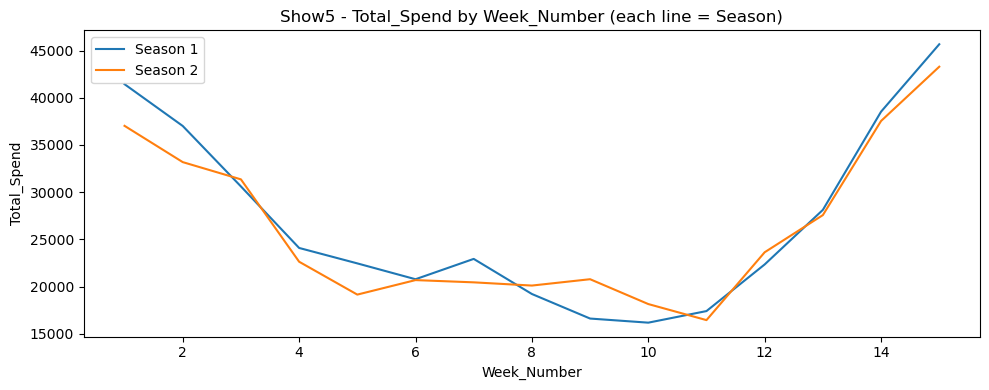

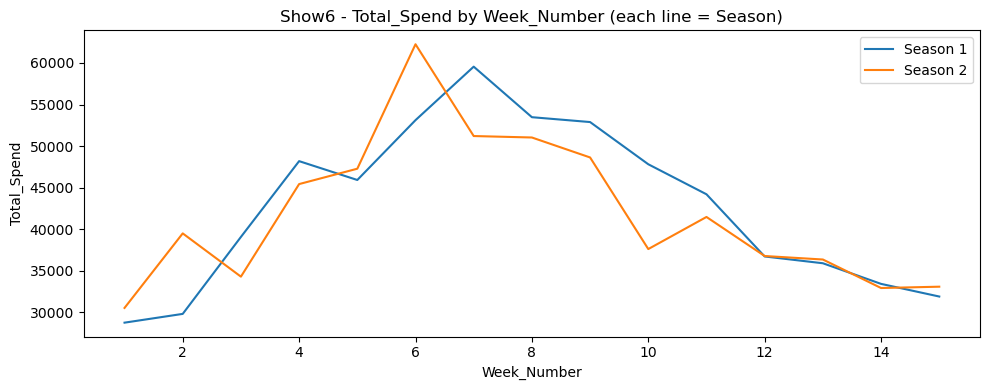

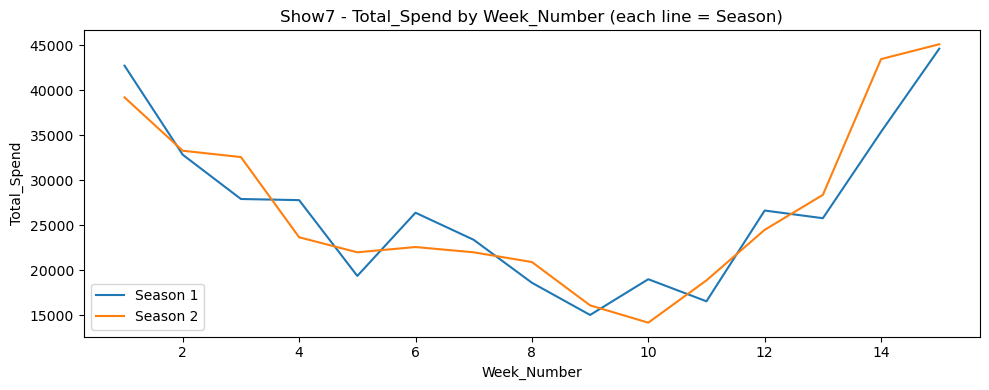

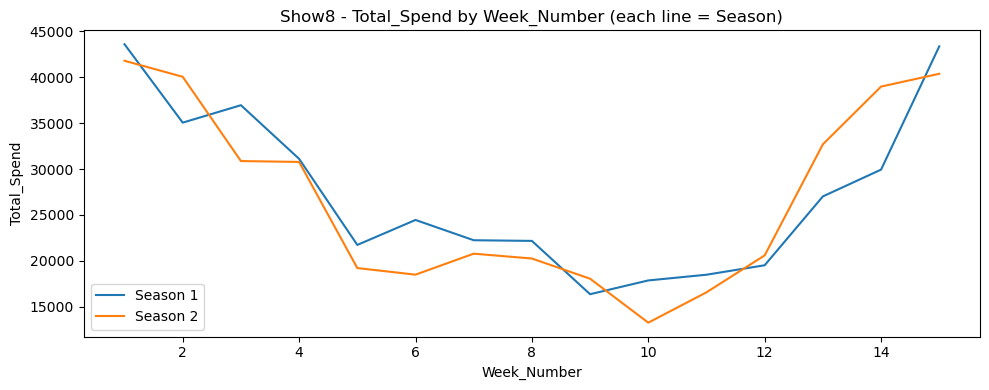

In [40]:
# Spend per week 

# Loop through each show in alphabetical order
# - weekly_df["Show"].unique() returns the list of shows
# - sorted() ensures the plots appear in a consistent order
for show in sorted(weekly_df["Show"].unique()):

    # Filter the dataset to include only rows for the current show
    tmp = weekly_df[weekly_df["Show"] == show]

    # Identify all seasons available for this show
    # Sorting ensures the seasons are plotted in chronological order
    seasons = sorted(tmp["Season"].unique())

    # Create a new figure for this show
    plt.figure(figsize=(10, 4))

    # Plot Total_Spend across weeks for each season
    # Each line represents one season of the show
    for s in seasons:
        # Filter to the current season and sort by week so the line progresses in time
        s_df = tmp[tmp["Season"] == s].sort_values("Week_Number")

        # Plot the weekly total marketing spend for this season
        plt.plot(s_df["Week_Number"], s_df["Total_Spend"], label=f"Season {s}")

    # Add descriptive title and axis labels
    plt.title(f"{show} - Total_Spend by Week_Number (each line = Season)")
    plt.xlabel("Week_Number")
    plt.ylabel("Total_Spend")

    # Display legend to differentiate seasons
    plt.legend()

    # Adjust layout to prevent overlapping labels
    plt.tight_layout()

    plt.show()

## 4. Campaign-Level Reporting

In [41]:
# Aggregate total impressions and Dollor spend by campaign by channel
# Here we define a campaign as a combination of Show and Season.
weekly_df["Campaign"] = weekly_df["Show"].astype(str) + "_S" + weekly_df["Season"].astype(str)

In [42]:
# =========================================================
# Build a Campaign × Channel spend summary table
# =========================================================
# Goal:
#   Create a tidy (long-format) table where each row represents
#   the total marketing spend for a given Campaign, Show, Season, and Channel.
#   This makes it easy to compare channel mix across campaigns and seasons.
# =========================================================

# 1) Reshape weekly_df from wide to long format
# - Original: one row per (Campaign, Show, Season) with separate spend columns
# - After melt: one row per (Campaign, Show, Season, Channel) with a single Spend column
campaign_channel_spend = pd.melt(
    weekly_df,
    id_vars=["Campaign", "Show", "Season"],                      # columns to keep as identifiers
    value_vars=["Network_TV_Spend", "Cable_TV_Spend", "Digital_Spend"],  # channel spend columns to unpivot
    var_name="Channel",                                          # name for the new channel column
    value_name="Spend"                                           # name for the new spend values column
)

# 2) Aggregate spend at the Campaign × Show × Season × Channel level
# - Sum Spend within each group to get total channel spend for the campaign
campaign_channel_spend = (
    campaign_channel_spend
    .groupby(["Campaign", "Show", "Season", "Channel"], as_index=False)
    .agg(Total_Spend=("Spend", "sum"))                           # total spend per group
    .sort_values(["Show", "Season", "Channel"])                  # sort for readability
)

# Preview the first 10 rows of the summarized table
campaign_channel_spend.head(10)

,Campaign,Show,Season,Channel,Total_Spend
0,Show1_S1,Show1,1,Cable_TV_Spend,"282,251.77"
1,Show1_S1,Show1,1,Digital_Spend,"235,209.81"
2,Show1_S1,Show1,1,Network_TV_Spend,"94,083.92"
3,Show1_S2,Show1,2,Cable_TV_Spend,"94,853.42"
4,Show1_S2,Show1,2,Digital_Spend,"237,133.54"
5,Show1_S2,Show1,2,Network_TV_Spend,"284,560.25"
6,Show1_S3,Show1,3,Cable_TV_Spend,"98,259.64"
7,Show1_S3,Show1,3,Digital_Spend,"245,649.09"
8,Show1_S3,Show1,3,Network_TV_Spend,"294,778.91"
9,Show1_S4,Show1,4,Cable_TV_Spend,"237,800.63"


In [43]:
# Note:
# The dataset reports Impressions as the total impressions across all channels.
# Since channel-level impressions are not available, impressions cannot be
# aggregated by channel directly.

# We aggregate total impressions across all weeks within the same campaign.

campaign_metrics = (
    weekly_df
    .groupby(["Campaign", "Show", "Season"], as_index=False)  # Group data by campaign (Show + Season)
    .agg(
        Total_Impressions=("Impressions", "sum")  # Sum impressions across all weeks within the campaign
    )
    .sort_values(["Show", "Season"])  # Sort results for easier readability
)

# Display the first 10 rows of the aggregated campaign-level metrics
campaign_metrics.head(10)

,Campaign,Show,Season,Total_Impressions
0,Show1_S1,Show1,1,1019242522
1,Show1_S2,Show1,2,1090814308
2,Show1_S3,Show1,3,1129985810
3,Show1_S4,Show1,4,1236563251
4,Show1_S5,Show1,5,970727643
5,Show2_S1,Show2,1,795336108
6,Show2_S2,Show2,2,641503612
7,Show2_S3,Show2,3,661133800
8,Show2_S4,Show2,4,692958813
9,Show2_S5,Show2,5,737018041


In [44]:
# =========================================================
# 1) Define Campaign (Show + Season)
# =========================================================
weekly_df = weekly_df.copy()
weekly_df["Campaign"] = weekly_df["Show"].astype(str) + "_S" + weekly_df["Season"].astype(str)

# =========================================================
# 2) Campaign-level total impressions
# Note:
# The dataset reports Impressions as the total impressions across all channels.
# Since channel-level impressions are not available, impressions cannot be
# aggregated by channel directly. We therefore aggregate impressions at the
# campaign level only.
# =========================================================
campaign_impressions = (
    weekly_df
    .groupby(["Campaign", "Show", "Season"], as_index=False)
    .agg(Total_Impressions=("Impressions", "sum"))
)

# =========================================================
# 3) Campaign × Channel total spend
# (Convert wide spend columns -> long format, then sum by campaign & channel)
# =========================================================
spend_long = pd.melt(
    weekly_df,
    id_vars=["Campaign", "Show", "Season"],
    value_vars=["Network_TV_Spend", "Cable_TV_Spend", "Digital_Spend"],
    var_name="Channel",
    value_name="Spend"
)

campaign_channel_spend = (
    spend_long
    .groupby(["Campaign", "Show", "Season", "Channel"], as_index=False)
    .agg(Total_Spend=("Spend", "sum"))
)

# Optional: make Channel labels match your screenshot style
channel_map = {
    "Network_TV_Spend": "Network TV",
    "Cable_TV_Spend": "Cable TV",
    "Digital_Spend": "Digital"
}
campaign_channel_spend["Channel"] = campaign_channel_spend["Channel"].replace(channel_map)

# =========================================================
# 4) Final table: Campaign × Channel spend + Campaign total impressions
# =========================================================
final_table = (
    campaign_channel_spend
    .merge(campaign_impressions, on=["Campaign", "Show", "Season"], how="left")
    .sort_values(["Show", "Season", "Channel"])
    .reset_index(drop=True)
)

final_table.head(10)

,Campaign,Show,Season,Channel,Total_Spend,Total_Impressions
0,Show1_S1,Show1,1,Cable TV,"282,251.77",1019242522
1,Show1_S1,Show1,1,Digital,"235,209.81",1019242522
2,Show1_S1,Show1,1,Network TV,"94,083.92",1019242522
3,Show1_S2,Show1,2,Cable TV,"94,853.42",1090814308
4,Show1_S2,Show1,2,Digital,"237,133.54",1090814308
5,Show1_S2,Show1,2,Network TV,"284,560.25",1090814308
6,Show1_S3,Show1,3,Cable TV,"98,259.64",1129985810
7,Show1_S3,Show1,3,Digital,"245,649.09",1129985810
8,Show1_S3,Show1,3,Network TV,"294,778.91",1129985810
9,Show1_S4,Show1,4,Cable TV,"237,800.63",1236563251


## 5. Performance Metrics (CPM & ROAS)

### 5.1 Show-Level Report

In [45]:
# =========================================================
# Show-level marketing performance report
# =========================================================
# Goal:
#   Summarize marketing scale (Spend, Impressions), outcomes (Revenue, Viewership),
#   and efficiency metrics (CPM, ROAS) for each Show.
# =========================================================

# 2) Aggregate to Show level
# - Sum spend, impressions, revenue, and viewership across all weeks for each show
# - Count how many weekly rows (weeks) exist for each show
show_report = (
    weekly_df.groupby("Show", as_index=False)
    .agg(
        Total_Spend=("Total_Spend", "sum"),              # total marketing spend across all weeks
        Total_Impressions=("Impressions", "sum"),        # total marketing ad impressions across all weeks
        Total_Revenue=("Revenue", "sum"),                # total revenue across all weeks
        Total_Viewership=("True_Viewership", "sum"),     # total viewers across all weeks
        Weeks=("Week_Number", "count"),                  # number of weekly observations for the show
    )
)

# 3) Compute CPM and ROAS (with divide-by-zero protection)
# CPM (Cost per Mille) = cost per 1,000 ad impressions
# - Lower CPM generally means cheaper reach
show_report["CPM"] = np.where(
    show_report["Total_Impressions"] > 0,
    show_report["Total_Spend"] / show_report["Total_Impressions"] * 1000,
    np.nan
)

# ROAS (Return on Ad Spend) = revenue generated per $1 of marketing spend
# - Higher ROAS indicates better revenue efficiency
show_report["ROAS"] = np.where(
    show_report["Total_Spend"] > 0,
    show_report["Total_Revenue"] / show_report["Total_Spend"],
    np.nan
)

# 4) sort and reset index for a clean, readable output table
show_report = show_report.sort_values("Show").reset_index(drop=True)

# Display key columns (first 8 shows)
show_report[[
    "Show", "Total_Spend", "Total_Impressions", "CPM",
    "Total_Revenue", "ROAS", "Weeks"
]].head(8)

,Show,Total_Spend,Total_Impressions,CPM,Total_Revenue,ROAS,Weeks
0,Show1,"3,095,680.99",5447333534,0.57,"10,167,655.65",3.28,75
1,Show2,"2,035,390.02",3527950374,0.58,"3,341,822.27",1.64,75
2,Show3,"3,158,355.95",5649499970,0.56,"9,899,449.82",3.13,75
3,Show4,"2,044,309.69",3526360166,0.58,"4,229,937.02",2.07,75
4,Show5,"795,338.20",1336781975,0.59,"1,749,209.16",2.20,30
5,Show6,"1,269,163.49",2376883662,0.53,"3,667,744.50",2.89,30
6,Show7,"808,066.08",1315513850,0.61,"1,196,136.37",1.48,30
7,Show8,"812,604.76",1457062170,0.56,"3,150,256.37",3.88,30


### 5.2 Campaign-Level Report

In [46]:
# =========================================================
# Campaign-level marketing performance report
# =========================================================
# Goal:
#   Create a "Campaign" identifier at the Show-Season level, then summarize
#   spend, impressions, revenue, and viewership for each campaign and compute
#   efficiency metrics (CPM and ROAS).
# =========================================================

# 1) Create a Campaign label for each Show-Season combination
# Example: "Show1_S3" means Show1, Season 3
weekly_df["Campaign"] = weekly_df["Show"].astype(str) + "_S" + weekly_df["Season"].astype(str)

# 2) Aggregate weekly metrics to the campaign level (Show + Season)
# - Sum Spend/Impressions/Revenue/Viewership across all weeks in the season
# - Count unique Week_Number to represent how many weeks are included for the campaign
campaign_report = (
    weekly_df.groupby(["Campaign", "Show", "Season"], as_index=False)
    .agg(
        Total_Spend=("Total_Spend", "sum"),              # total marketing spend for the campaign
        Total_Impressions=("Impressions", "sum"),        # total marketing ad impressions for the campaign
        Total_Revenue=("Revenue", "sum"),                # total revenue during the campaign window
        Total_Viewership=("True_Viewership", "sum"),     # total viewers during the campaign window
        Weeks=("Week_Number", "nunique"),                # number of unique weeks in the campaign
    )
)

# 3) Compute CPM (Cost per 1,000 marketing ad impressions)
# - Lower CPM generally indicates cheaper reach
# - Use np.where to avoid division by zero when impressions are 0
campaign_report["CPM"] = np.where(
    campaign_report["Total_Impressions"] > 0,
    campaign_report["Total_Spend"] / campaign_report["Total_Impressions"] * 1000,
    np.nan
)

# 4) Compute ROAS (Return on Ad Spend)
# - Higher ROAS indicates higher revenue generated per $1 spent
# - Use np.where to avoid division by zero when spend is 0
campaign_report["ROAS"] = np.where(
    campaign_report["Total_Spend"] > 0,
    campaign_report["Total_Revenue"] / campaign_report["Total_Spend"],
    np.nan
)

# 5) Sort results by Show and Season for easier reading, then preview the first 15 rows
campaign_report.sort_values(["Show", "Season"]).head(15)

,Campaign,Show,Season,Total_Spend,Total_Impressions,Total_Revenue,Total_Viewership,Weeks,CPM,ROAS
0,Show1_S1,Show1,1,"611,545.51",1019242522,"2,010,183.20","2,862,894.55",15,0.60,3.29
1,Show1_S2,Show1,2,"616,547.22",1090814308,"1,995,564.27","2,854,613.12",15,0.57,3.24
2,Show1_S3,Show1,3,"638,687.63",1129985810,"2,063,993.92","2,929,227.02",15,0.57,3.23
3,Show1_S4,Show1,4,"618,281.63",1236563251,"2,145,882.34","3,055,964.30",15,0.50,3.47
4,Show1_S5,Show1,5,"610,619.00",970727643,"1,952,031.90","2,779,763.51",15,0.63,3.20
5,Show2_S1,Show2,1,"402,832.57",795336108,"717,494.72","1,025,210.55",15,0.51,1.78
6,Show2_S2,Show2,2,"403,526.47",641503612,"652,551.48","930,530.70",15,0.63,1.62
7,Show2_S3,Show2,3,"396,680.28",661133800,"651,829.14","935,002.23",15,0.60,1.64
8,Show2_S4,Show2,4,"415,775.29",692958813,"655,502.30","936,245.58",15,0.60,1.58
9,Show2_S5,Show2,5,"416,575.41",737018041,"664,444.64","950,230.57",15,0.57,1.60


### 5.3 Efficiency Trends

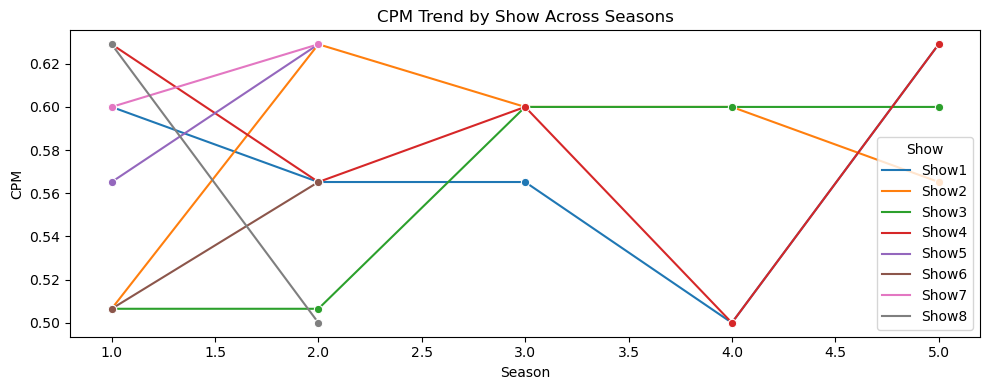

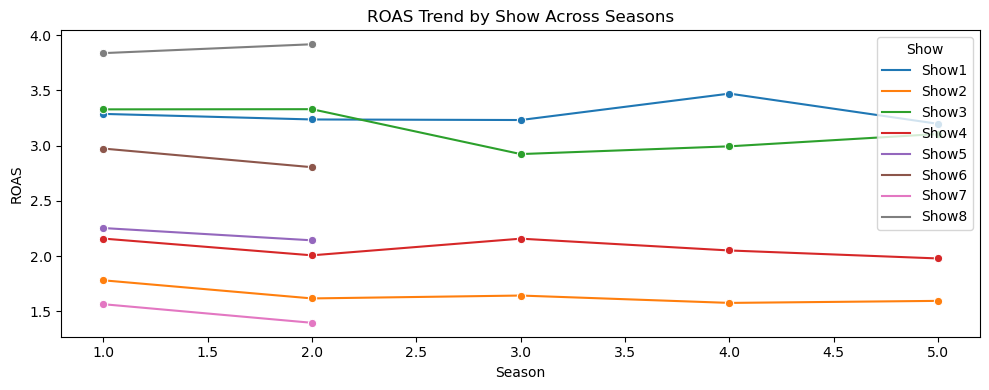

In [47]:
# =========================================================
# Plot CPM trend across seasons for each show
# =========================================================
# Each line represents a show, and each point represents the CPM
# for a specific season. This helps visualize how the cost efficiency
# (cost per 1,000 impressions) changes across seasons.

plt.figure(figsize=(10, 4))

# Line chart showing CPM across seasons, grouped by Show
# marker="o" adds points to highlight each season observation
sns.lineplot(data=campaign_report, x="Season", y="CPM", hue="Show", marker="o")

# Add chart title and axis labels
plt.title("CPM Trend by Show Across Seasons")
plt.xlabel("Season")
plt.ylabel("CPM")

# Adjust layout to avoid label overlap
plt.tight_layout()

# Display the plot
plt.show()


# =========================================================
# Plot ROAS trend across seasons for each show
# =========================================================
# Each line represents a show, showing how return on ad spend (ROAS)
# evolves across seasons. This helps identify whether marketing
# efficiency is improving or declining over time.

plt.figure(figsize=(10, 4))

# Line chart showing ROAS across seasons, grouped by Show
sns.lineplot(data=campaign_report, x="Season", y="ROAS", hue="Show", marker="o")

# Add chart title and axis labels
plt.title("ROAS Trend by Show Across Seasons")
plt.xlabel("Season")
plt.ylabel("ROAS")

# Adjust layout for readability
plt.tight_layout()

# Display the plot
plt.show()

### Efficiency Trend Takeaways

- CPM is fairly stable across seasons, generally ranging from about **0.50 to 0.63**, which suggests media buying efficiency is reasonably consistent over time.
- ROAS is also fairly stable within each show, but the level differs by title. **Show8** is highest overall, while **Show1** and **Show3** are consistently strong.
- These stable but show-specific differences reinforce the need for **show fixed effects** in the MMM.


## 6. Scenario Questions (Medallion Architecture)

### 6.1 Bronze / Silver / Gold Layers

**Q1. Briefly explain the purpose and main challenges of each medallion layer in 2-3 sentences.**


### Answer

**Bronze layer**
- **Purpose:** Store raw source data exactly as received so the team preserves lineage, auditability, and recoverability.
- **Main challenges:** schema drift, ingestion reliability at scale, and retaining historical raw snapshots without data loss.

**Silver layer**
- **Purpose:** Clean and standardize the raw data by fixing types, handling missing values, removing duplicates, and applying transformation logic.
- **Main challenges:** keeping business rules consistent, absorbing upstream schema changes, and preventing downstream breakage when transformations evolve.

**Gold layer**
- **Purpose:** Publish business-ready tables designed for reporting, modeling, and decision support.
- **Main challenges:** metric consistency, stable business definitions, and performance for analytical workloads.


### 6.2 Handling Upstream Schema Changes

**Q2. Given a sudden schema change upstream, describe your process for ensuring the downstream Silver and Gold layers still function without interruption.**


My goal is to detect the schema change early, isolate the blast radius, adapt transformations safely, and protect downstream consumers. I would use the following four-step process:

**1. Detect the change quickly**
- Validate each incoming batch against the expected schema at ingestion time.
- Trigger alerts for new columns, removed fields, type changes, or abnormal null patterns before downstream jobs run.

**2. Contain the change in Bronze**
- Keep Bronze ingestion as permissive as possible so raw data can continue landing even when the schema evolves.
- Treat Bronze as a buffer that preserves history and prevents upstream changes from immediately breaking Silver and Gold.

**3. Update Silver transformation logic**
- Adjust parsing, typing, and transformation rules to handle the new schema explicitly.
- Add tests and data quality checks so the Silver contract stays stable even if Bronze is more flexible.

**4. Protect Gold consumers**
- Promote the updated schema through staged releases or versioned tables.
- Validate key business metrics and regression-test dependent dashboards or models before full rollout.

Data lineage and dependency tracking make this process much faster because they show exactly which downstream tables, dashboards, and models are affected.


### 6.3 Data Lineage & Monitoring

**Q3. Describe how you would implement data lineage and monitoring across layers to quickly identify and resolve data quality issues.**


I would combine lineage, monitoring, and root-cause workflows so issues can be detected quickly and traced precisely.

**Lineage**
- Capture table-level and column-level lineage across Bronze, Silver, and Gold.
- Log each job's inputs, outputs, transformation version, execution time, and row counts in an audit table so any Gold metric can be traced back to its raw source.

**Monitoring**
- In Silver, monitor schema validity, null rates on key fields, uniqueness, data types, and acceptable value ranges.
- In Gold, monitor business-facing checks such as aggregation consistency, KPI stability, and week-over-week anomalies in spend, impressions, viewership, and revenue.
- Also monitor freshness, row-count shifts, and pipeline success or failure.

**Resolution process**
- When an alert fires, use lineage metadata to identify the exact job, batch, and upstream dependency where the issue started.
- Isolate the affected batch, fix the root cause, and rerun only the impacted downstream assets.

This approach reduces downtime because diagnosis is faster and remediation is targeted rather than manual or exploratory.


## 7. Modeling (Marketing Mix Model)

This section answers the core business question: which channels appear to drive viewership after controlling for show baseline, holiday effects, and lead-in boosts? I estimate three increasingly realistic MMM specifications so the reader can see how the story changes when carryover and saturation are introduced.


### 7.1 OLS Model Assumptions

- **Linearity:** predictors are assumed to have a linear relationship with expected viewership after transformation.
- **Exogeneity:** marketing inputs are assumed not to be correlated with the error term.
- **No perfect multicollinearity:** predictors should not be exact linear combinations of one another.
- **Independent errors:** residuals should not be strongly dependent across observations.
- **Homoskedasticity or robust standard errors:** I use HC3 robust standard errors to reduce sensitivity to unequal variance.


\[
\text{Viewership}_t =
\beta_0
+ \beta_1 \,\text{Network Spend}_t
+ \beta_2 \,\text{Cable Spend}_t
+ \beta_3 \,\text{Digital Spend}_t
+ \beta_4 \,\text{Holiday}_t
+ \beta_5 \,\text{LeadIn}_t
+ \text{Show Fixed Effects}
+ \varepsilon_t
\]


### 7.2 Model 0 — Baseline MMM

In [48]:
# =========================================================
# MMM on Gold weekly data (Per-show time-based split)
# Model 0: Log-transformed spend (no adstock, no saturation)
# Goal: estimate the marginal impact of each spend channel on True_Viewership.
# =========================================================
# 0) Start from the cleaned Gold weekly dataset
m0_df = weekly_df.copy()

# 1) MMM-friendly transformation:
# Use log(1 + spend) to reduce skewness and capture diminishing returns.
m0_df["log_net"] = np.log1p(m0_df["Network_TV_Spend"])
m0_df["log_cable"] = np.log1p(m0_df["Cable_TV_Spend"])
m0_df["log_dig"] = np.log1p(m0_df["Digital_Spend"])

# =========================================================
# 2) Per-show time split
# Why: shows have different start/end dates. A single global date split could
# overweight the evaluation toward shows that run later. Instead, we split
# within each show: earlier weeks = train, later weeks = test.
# =========================================================
train_parts = []
test_parts = []

for show, g in m0_df.groupby("Show"):
    # Sort each show's data chronologically
    g = g.sort_values("Air_Date").reset_index(drop=True)

    # Use the first 80% of weeks for training and last 20% for testing
    split_idx = int(len(g) * 0.8)

    train_parts.append(g.iloc[:split_idx])
    test_parts.append(g.iloc[split_idx:])

m0_train = pd.concat(train_parts, ignore_index=True)
m0_test = pd.concat(test_parts, ignore_index=True)

print("Train date range:", m0_train["Air_Date"].min(), "to", m0_train["Air_Date"].max())
print("Test  date range:", m0_test["Air_Date"].min(), "to", m0_test["Air_Date"].max())
print("Train rows:", len(m0_train), "Test rows:", len(m0_test))


# =========================================================
# 3) Build feature matrix X and target y
# Features:
# - log_net, log_cable, log_dig: transformed channel spends
# - Holiday, LeadIn_Bonus: control variables
# - Show fixed effects: one-hot encoding of Show to control baseline differences
# Target:
# - True_Viewership (preferred over Revenue since Revenue is proportional to viewers)
# =========================================================
features = ["log_net", "log_cable", "log_dig", "Holiday", "LeadIn_Bonus"]

# One-hot encode Show
X_train = pd.get_dummies(m0_train[features + ["Show"]], columns=["Show"], drop_first=True)
X_test  = pd.get_dummies(m0_test[features + ["Show"]], columns=["Show"], drop_first=True)

# Align test columns to train columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Define targets
y_train = m0_train["True_Viewership"].astype(float)
y_test  = m0_test["True_Viewership"].astype(float)

# Add intercept
X_train = sm.add_constant(X_train)
X_test  = sm.add_constant(X_test)
# =========================================================
# 4) Fit the MMM using OLS
# Use HC3 robust standard errors to reduce sensitivity to heteroskedasticity.
# =========================================================
model0 = sm.OLS(y_train, X_train).fit(cov_type="HC3")
print(model0.summary())

# =========================================================
# 5) Evaluate on the test set
# =========================================================
y_pred = model0.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("\nModel0 Test RMSE:", rmse)
print("Model0 Test R^2 :", r2)

# =========================================================
# 6) Extract the main channel coefficients
# =========================================================
coef_table = model0.params[["log_net", "log_cable", "log_dig"]].to_frame("coef")
print("\nEstimated channel effects (log1p spend):")
print(coef_table)

Train date range: 2020-09-06 00:00:00 to 2025-03-09 00:00:00
Test  date range: 2024-08-08 00:00:00 to 2025-04-20 00:00:00
Train rows: 336 Test rows: 84
                            OLS Regression Results                            
Dep. Variable:        True_Viewership   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     231.2
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          1.56e-150
Time:                        17:20:21   Log-Likelihood:                -3883.9
No. Observations:                 336   AIC:                             7794.
Df Residuals:                     323   BIC:                             7843.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|  

### Model 0 Takeaways


- In the baseline log-spend MMM, **Cable TV** and **Network TV** are both statistically significant and positively associated with weekly viewership, with Cable TV showing the largest estimated effect.
- **Digital spend** is also positive and significant, but its contribution is smaller than the TV channels.
- Among the controls, **LeadIn_Bonus** is significant and positive, while **Holiday** is not statistically meaningful once other factors are included.
- Show fixed effects are important, confirming that baseline popularity differences across shows are large enough to bias channel estimates if they are omitted.


### 7.3 Model 1 — Adstock MMM

### Adstock Intro

Advertising often affects consumers beyond the week in which spend occurs. Adstock captures that carryover by allowing part of last week's advertising effect to persist into the current week. In practical terms, current response is modeled as today's spend plus a decayed remainder of prior spend.


In [49]:
# =========================================================
# Model 1: MMM with Adstock + log1p
# - Tune adstock decay (alpha) per channel via grid search
# - Objective: maximize out-of-sample test R² using per-show time split
# =========================================================

#-----------------------------
# 0) Helper: geometric adstock
# -----------------------------
def geometric_adstock(x: np.ndarray, alpha: float) -> np.ndarray:
    # Convert input series to a NumPy array of floats
    # This ensures numerical operations work consistently
    x = np.asarray(x, dtype=float)

    # Create an array of zeros to store the adstock values
    # It has the same length as the original spend series
    out = np.zeros_like(x, dtype=float)

    # Iterate through each time period
    for t in range(len(x)):
        # For the first observation (t = 0), there is no previous carryover
        # so adstock equals the current spend
        if t == 0:
            out[t] = x[t]
        else:
            # For later periods:
            # adstock = current spend + decayed carryover from previous period
            out[t] = x[t] + alpha * out[t-1]
    return out

# ---------- 1) Candidate alpha values ----------
alpha_grid = [0.1, 0.3, 0.5, 0.7, 0.9]

# ---------- 2) Base dataframe----------
m1_df = weekly_df.copy()
m1_df = m1_df.sort_values(["Show", "Air_Date"]).reset_index(drop=True)

# ---------- 3) Grid search over (alpha_net, alpha_cable, alpha_dig) ----------
m1_results = []

for a_net, a_cable, a_dig in product(alpha_grid, alpha_grid, alpha_grid):
    tmp = m1_df.copy()

    # ---------------------------------------------------------
    # 3A) Compute adstock per show (IMPORTANT: per-show only)
    # - groupby("Show") ensures carryover does NOT leak across shows
    # - transform(...) returns a series aligned to original rows
    # ---------------------------------------------------------
    tmp["net_ad"] = tmp.groupby("Show")["Network_TV_Spend"].transform(
        lambda s: geometric_adstock(s.values, a_net)
    )
    tmp["cable_ad"] = tmp.groupby("Show")["Cable_TV_Spend"].transform(
        lambda s: geometric_adstock(s.values, a_cable)
    )
    tmp["dig_ad"] = tmp.groupby("Show")["Digital_Spend"].transform(
        lambda s: geometric_adstock(s.values, a_dig)
    )


    # ---------------------------------------------------------
    # 3B) Diminishing returns transform
    # Using log1p to reduce skewness and approximate diminishing returns
    # ---------------------------------------------------------
    tmp["log_net_ad"] = np.log1p(tmp["net_ad"])
    tmp["log_cable_ad"] = np.log1p(tmp["cable_ad"])
    tmp["log_dig_ad"] = np.log1p(tmp["dig_ad"])

    # ---------------------------------------------------------
    # 3C) Per-show time split (80% train / 20% test within each show)
    # This ensures "past -> future" evaluation for each show regardless of
    # different show start/end dates.
    # ---------------------------------------------------------
    train_parts, test_parts = [], []
    for show, g in tmp.groupby("Show"):
        g = g.sort_values("Air_Date").reset_index(drop=True)
        split_idx = int(len(g) * 0.8)
        train_parts.append(g.iloc[:split_idx])
        test_parts.append(g.iloc[split_idx:])

    m1_train = pd.concat(train_parts, ignore_index=True)
    m1_test  = pd.concat(test_parts, ignore_index=True)


    # ---------------------------------------------------------
    # 3D) Build X/y for OLS
    # ---------------------------------------------------------
    m1_features = ["log_net_ad", "log_cable_ad", "log_dig_ad", "Holiday", "LeadIn_Bonus"]

    X_train = pd.get_dummies(m1_train[m1_features + ["Show"]], columns=["Show"], drop_first=True)
    X_test  = pd.get_dummies(m1_test[m1_features + ["Show"]], columns=["Show"], drop_first=True)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train = m1_train["True_Viewership"].astype(float)
    y_test  = m1_test["True_Viewership"].astype(float)

    X_train = sm.add_constant(X_train)
    X_test  = sm.add_constant(X_test)

    # 3E) Fit & evaluate
    model1_tmp = sm.OLS(y_train, X_train).fit(cov_type="HC3")
    y_pred = model1_tmp.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)

    m1_results.append({
        "alpha_net": a_net,
        "alpha_cable": a_cable,
        "alpha_dig": a_dig,
        "test_r2": test_r2
    })

# =========================================================
# 4) Pick best alphas
# =========================================================
m1_grid_results = (
    pd.DataFrame(m1_results)
      .sort_values("test_r2", ascending=False)
      .reset_index(drop=True)
)

print("Top 10 alpha combos by test R²:")
print(m1_grid_results.head(10))

best = m1_grid_results.iloc[0]
best_net = float(best["alpha_net"])
best_cable = float(best["alpha_cable"])
best_dig = float(best["alpha_dig"])

print(f"\nBest alphas: net={best_net}, cable={best_cable}, dig={best_dig}")
print(f"Best test R²: {best['test_r2']:.4f}")


# =========================================================
# 5) Refit final model using the best alphas
# =========================================================

m1_final_df = m1_df.copy()

m1_final_df["net_ad"] = m1_final_df.groupby("Show")["Network_TV_Spend"].transform(
    lambda s: geometric_adstock(s.values, best_net)
)
m1_final_df["cable_ad"] = m1_final_df.groupby("Show")["Cable_TV_Spend"].transform(
    lambda s: geometric_adstock(s.values, best_cable)
)
m1_final_df["dig_ad"] = m1_final_df.groupby("Show")["Digital_Spend"].transform(
    lambda s: geometric_adstock(s.values, best_dig)
)

m1_final_df["log_net_ad"] = np.log1p(m1_final_df["net_ad"])
m1_final_df["log_cable_ad"] = np.log1p(m1_final_df["cable_ad"])
m1_final_df["log_dig_ad"] = np.log1p(m1_final_df["dig_ad"])

# Per-show split again
train_parts, test_parts = [], []
for show, g in m1_final_df.groupby("Show"):
    g = g.sort_values("Air_Date").reset_index(drop=True)
    split_idx = int(len(g) * 0.8)
    train_parts.append(g.iloc[:split_idx])
    test_parts.append(g.iloc[split_idx:])

m1_train = pd.concat(train_parts, ignore_index=True)
m1_test  = pd.concat(test_parts, ignore_index=True)

m1_features = ["log_net_ad", "log_cable_ad", "log_dig_ad", "Holiday", "LeadIn_Bonus"]

X_train = pd.get_dummies(m1_train[m1_features + ["Show"]], columns=["Show"], drop_first=True)
X_test  = pd.get_dummies(m1_test[m1_features + ["Show"]], columns=["Show"], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = m1_train["True_Viewership"].astype(float)
y_test  = m1_test["True_Viewership"].astype(float)

X_train = sm.add_constant(X_train)
X_test  = sm.add_constant(X_test)

model1 = sm.OLS(y_train, X_train).fit(cov_type="HC3")
print("\nFinal Model 1 summary (best alphas):")
print(model1.summary())

m1_pred = model1.predict(X_test)
print("\nFinal Model 1 test R²:", r2_score(y_test, m1_pred))

Top 10 alpha combos by test R²:
   alpha_net  alpha_cable  alpha_dig  test_r2
0       0.10         0.70       0.70     0.91
1       0.10         0.70       0.90     0.91
2       0.10         0.90       0.50     0.91
3       0.10         0.90       0.70     0.91
4       0.30         0.70       0.70     0.91
5       0.10         0.90       0.30     0.91
6       0.30         0.70       0.90     0.90
7       0.10         0.90       0.10     0.90
8       0.10         0.70       0.50     0.90
9       0.30         0.90       0.50     0.90

Best alphas: net=0.1, cable=0.7, dig=0.7
Best test R²: 0.9097

Final Model 1 summary (best alphas):
                            OLS Regression Results                            
Dep. Variable:        True_Viewership   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     242.9
Date:                Wed, 04 Mar 2026   Prob 

### Model 1 Insights

- Adding adstock improves out-of-sample fit, increasing the best test performance to about **R^2 = 0.9097**. This suggests lagged media effects matter in this dataset.
- The best carryover pattern differs by channel: **Network TV alpha = 0.1**, **Cable alpha = 0.7**, and **Digital alpha = 0.7**. That implies Network TV is more immediate, while Cable and Digital persist longer.
- Channel ranking remains stable: **Cable** is strongest, then **Network**, then **Digital**. All three are positive and statistically significant in the best model.
- **LeadIn_Bonus** continues to matter, while **Holiday** remains unimportant after controls.

### Model 1 Challenges

- Residual autocorrelation remains strong, with **Durbin-Watson around 0.65**, so the model still misses some time dynamics.
- Adstock helps with carryover, but it still does not fully capture nonlinear response at higher spend levels.


### 7.4 Model 2 — Adstock + Saturation MMM
### Saturation Intro

Saturation reflects diminishing returns: as spend grows, each additional dollar tends to generate a smaller incremental outcome. I model that effect with a Hill curve so the MMM can capture both carryover and flattening response at higher spend levels.

`sat(x) = x^slope / (x^slope + half_sat^slope)`

- higher alpha means longer carryover
- larger half-saturation means the channel saturates later
- higher slope means a sharper transition into saturation


In [50]:
# =========================================================
# Model 2: MMM with Adstock + Saturation (Hill)
#
# Goal:
#   Build a marketing mix model to estimate the effect of each spend channel
#   on weekly True_Viewership, while accounting for:
#     (1) Carryover effects (Adstock)
#     (2) Diminishing returns (Saturation / Hill curve)

# =========================================================

# 0) Helper: Hill saturation
# -----------------------------
def hill_saturation(x: np.ndarray, half_sat: float, slope: float) -> np.ndarray:
    """
    Hill function for diminishing returns (saturation):
        sat(x) = x^slope / (x^slope + half_sat^slope)

    - x: non-negative input (e.g., adstocked spend)
    - half_sat: value where sat(x)=0.5 (controls "where" it saturates)
    - slope: curve steepness (higher -> sharper transition)
    Output is in (0,1). You can scale it later if needed.
    """
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0, None)
    eps = 1e-12
    num = np.power(x + eps, slope)
    den = num + np.power(half_sat + eps, slope)
    return num / den

# =========================================================
# 1) Fix adstock decay (alpha) using the best values found in Model 1
# =========================================================
alpha_net, alpha_cable, alpha_dig = best_net, best_cable, best_dig

# =========================================================
# 2) Load and prepare Gold weekly data
# =========================================================
m2_df = weekly_df.copy()
m2_df = m2_df.sort_values(["Show", "Air_Date"]).reset_index(drop=True)

# =========================================================
# 3) Compute adstock on the FULL time series, per show
#    IMPORTANT: We do this BEFORE the train/test split.
#    Otherwise, test-period adstock would miss carryover from training weeks.
# =========================================================
m2_df["net_ad"] = m2_df.groupby("Show")["Network_TV_Spend"].transform(
    lambda s: geometric_adstock(s.values, alpha_net)
)
m2_df["cable_ad"] = m2_df.groupby("Show")["Cable_TV_Spend"].transform(
    lambda s: geometric_adstock(s.values, alpha_cable)
)
m2_df["dig_ad"] = m2_df.groupby("Show")["Digital_Spend"].transform(
    lambda s: geometric_adstock(s.values, alpha_dig)
)

# =========================================================
# 4) Choose default half-saturation points (theta) from data
#    A common heuristic: half_sat = median(adstocked input)
#    This makes sat(x)=0.5 around the typical spend level.
# =========================================================
med_net = float(np.nanmedian(m2_df["net_ad"].values))
med_cable = float(np.nanmedian(m2_df["cable_ad"].values))
med_dig = float(np.nanmedian(m2_df["dig_ad"].values))

# =========================================================
# 5) Prepare per-show time split ONCE (80/20 within each show)
#    This avoids an unfair global split because shows have different start/end dates.
# =========================================================
train_parts, test_parts = [], []
for show, g in m2_df.groupby("Show"):
    g = g.sort_values("Air_Date").reset_index(drop=True)
    split_idx = int(len(g) * 0.8)
    train_parts.append(g.iloc[:split_idx])
    test_parts.append(g.iloc[split_idx:])

m2_train_base = pd.concat(train_parts, ignore_index=True)
m2_test_base  = pd.concat(test_parts, ignore_index=True)

print("Train date range:", m2_train_base["Air_Date"].min(), "to", m2_train_base["Air_Date"].max())
print("Test  date range:", m2_test_base["Air_Date"].min(), "to", m2_test_base["Air_Date"].max())
print("Train rows:", len(m2_train_base), "Test rows:", len(m2_test_base))
# =========================================================
# 6) Tune saturation parameters with a SMALL grid search
#    We tune two parameters:
#      - slope (gamma): steepness of the Hill curve
#      - half_mult: scales the half-saturation point relative to the median
#
#    For simplicity, we use the SAME slope and SAME half_mult for all channels.
# =========================================================
slope_grid = [1.0, 1.5, 2.0]
half_mult_grid = [0.5, 1.0, 2.0]

m2_results = []

for slope in slope_grid:
    for half_mult in half_mult_grid:
        # Compute channel-specific half-saturation values (theta)
        # Using median(adstock) * multiplier:
        # - larger multiplier => saturates later (needs more spend to reach 0.5)
        # - smaller multiplier => saturates earlier
        half_net = med_net * half_mult
        half_cable = med_cable * half_mult
        half_dig = med_dig * half_mult

        # Copy train/test splits so we can add temporary saturation columns
        tr = m2_train_base.copy()
        te = m2_test_base.copy()

        # ---------------------------------------------------------
        # Apply saturation AFTER adstock
        # These saturated variables become the media inputs to the regression.
        # ---------------------------------------------------------
        tr["net_sat"] = hill_saturation(tr["net_ad"].values, half_sat=half_net, slope=slope)
        tr["cable_sat"] = hill_saturation(tr["cable_ad"].values, half_sat=half_cable, slope=slope)
        tr["dig_sat"] = hill_saturation(tr["dig_ad"].values, half_sat=half_dig, slope=slope)

        te["net_sat"] = hill_saturation(te["net_ad"].values, half_sat=half_net, slope=slope)
        te["cable_sat"] = hill_saturation(te["cable_ad"].values, half_sat=half_cable, slope=slope)
        te["dig_sat"] = hill_saturation(te["dig_ad"].values, half_sat=half_dig, slope=slope)

        # ---------------------------------------------------------
        # Build regression design matrix X and target y
        # Include:
        #   - saturated media inputs
        #   - controls (Holiday, LeadIn_Bonus)
        #   - show fixed effects (one-hot Show)
        # ---------------------------------------------------------
 
        m2_features = ["net_sat", "cable_sat", "dig_sat", "Holiday", "LeadIn_Bonus"]

        X_train = pd.get_dummies(tr[m2_features + ["Show"]], columns=["Show"], drop_first=True)
        X_test  = pd.get_dummies(te[m2_features + ["Show"]], columns=["Show"], drop_first=True)
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

        y_train = tr["True_Viewership"].astype(float)
        y_test  = te["True_Viewership"].astype(float)

        X_train = sm.add_constant(X_train)
        X_test  = sm.add_constant(X_test)

        # ---------------------------------------------------------
        # Fit OLS with HC3 robust SE and evaluate on the TEST split
        # ---------------------------------------------------------
        model2_tmp = sm.OLS(y_train, X_train).fit(cov_type="HC3")
        pred = model2_tmp.predict(X_test)

        test_r2 = r2_score(y_test, pred)
        test_rmse = mean_squared_error(y_test, pred, squared=False)

        m2_results.append({
            "slope": slope,
            "half_mult": half_mult,
            "test_r2": test_r2,
            "test_rmse": test_rmse
        })

# Collect grid search results and pick the best by test R² (tie-break by RMSE)
m2_grid = (
    pd.DataFrame(m2_results)
      .sort_values(["test_r2", "test_rmse"], ascending=[False, True])
      .reset_index(drop=True)
)

print("\nTop tuning results (sorted by test R², then RMSE):")
print(m2_grid.head(10))

best_slope = float(m2_grid.loc[0, "slope"])
best_half_mult = float(m2_grid.loc[0, "half_mult"])
print(f"\nBest saturation params: slope={best_slope}, half_mult={best_half_mult}")


# =========================================================
# 7) Refit FINAL tuned model
# =========================================================
half_net = med_net * best_half_mult
half_cable = med_cable * best_half_mult
half_dig = med_dig * best_half_mult

m2_train = m2_train_base.copy()
m2_test  = m2_test_base.copy()

# Apply saturation using best parameters
m2_train["net_sat"] = hill_saturation(m2_train["net_ad"].values, half_sat=half_net, slope=best_slope)
m2_train["cable_sat"] = hill_saturation(m2_train["cable_ad"].values, half_sat=half_cable, slope=best_slope)
m2_train["dig_sat"] = hill_saturation(m2_train["dig_ad"].values, half_sat=half_dig, slope=best_slope)

m2_test["net_sat"] = hill_saturation(m2_test["net_ad"].values, half_sat=half_net, slope=best_slope)
m2_test["cable_sat"] = hill_saturation(m2_test["cable_ad"].values, half_sat=half_cable, slope=best_slope)
m2_test["dig_sat"] = hill_saturation(m2_test["dig_ad"].values, half_sat=half_dig, slope=best_slope)

m2_features = ["net_sat", "cable_sat", "dig_sat", "Holiday", "LeadIn_Bonus"]

X_train = pd.get_dummies(m2_train[m2_features + ["Show"]], columns=["Show"], drop_first=True)
X_test  = pd.get_dummies(m2_test[m2_features + ["Show"]], columns=["Show"], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = m2_train["True_Viewership"].astype(float)
y_test  = m2_test["True_Viewership"].astype(float)

X_train = sm.add_constant(X_train)
X_test  = sm.add_constant(X_test)

final_model2 = sm.OLS(y_train, X_train).fit(cov_type="HC3")

print("\n=== Tuned Adstock + Saturation Model 2 Summary ===")
print(final_model2.summary())

m2_pred = final_model2.predict(X_test)
final_rmse = mean_squared_error(y_test, m2_pred, squared=False)
final_r2 = r2_score(y_test, m2_pred)

print("\nModel 2 (Test) RMSE:", final_rmse)
print("Model 2 (Test) R^2 :", final_r2)

print("\nKey channel coefficients (saturation inputs):")
print(final_model2.params[["net_sat", "cable_sat", "dig_sat"]])

Train date range: 2020-09-06 00:00:00 to 2025-03-09 00:00:00
Test  date range: 2024-08-08 00:00:00 to 2025-04-20 00:00:00
Train rows: 336 Test rows: 84

Top tuning results (sorted by test R², then RMSE):
   slope  half_mult  test_r2  test_rmse
0   1.50       2.00     0.91  17,768.42
1   2.00       2.00     0.91  17,809.60
2   1.00       2.00     0.91  17,891.97
3   1.00       1.00     0.91  18,151.28
4   1.50       1.00     0.91  18,164.67
5   2.00       1.00     0.91  18,211.65
6   1.00       0.50     0.91  18,489.91
7   1.50       0.50     0.90  18,831.33
8   2.00       0.50     0.90  19,177.65

Best saturation params: slope=1.5, half_mult=2.0

=== Tuned Adstock + Saturation Model 2 Summary ===
                            OLS Regression Results                            
Dep. Variable:        True_Viewership   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:     

### Model 2 Insights

- This is the best-performing specification, with **train R^2 = 0.874**, **adjusted R^2 = 0.869**, **test R^2 = 0.9135**, and **RMSE about 17,768 viewers**.
- After accounting for both carryover and diminishing returns, all three channels remain positive and highly significant. **Cable TV** is still the strongest driver, while **Network TV** and **Digital** are meaningful but smaller.
- **LeadIn_Bonus** remains significant and positive.
- **Holiday** still does not materially explain viewership in this dataset.
- Large baseline differences across shows remain important, which validates the use of show fixed effects.

### Model 2 Challenges

- **Durbin-Watson remains low at about 0.69**, so some serial dependence is still left in the residuals.
- Saturation is tuned with one shared slope and half-saturation multiplier across channels, which is a useful simplification for the case but not the most flexible production setup.

### Model 2 Recommended Next Steps

- Tune channel-specific saturation parameters instead of sharing one slope and half-saturation rule across channels.
- Use rolling or walk-forward validation instead of a single 80/20 split within each show.
- Test additional controls for seasonality, momentum, or competitive context if those data become available.


### 7.5 Model Comparison

- **Model 0:** `log1p(spend)` with test **R^2 = 0.8956**
- **Model 1:** `adstock(spend) -> log1p(adstock)` with tuned alphas and test **R^2 = 0.9097**
- **Model 2:** `adstock(spend) -> Hill saturation` with tuned parameters and test **R^2 = 0.9135**

**Comparison summary**
- The best model is **Model 2**, which adds both carryover and diminishing returns.
- The business story is stable across models: **Cable TV** is strongest, **Network TV** is second, and **Digital** remains positive but smaller.
- **LeadIn_Bonus** is consistently helpful, while **Holiday** is consistently weak.


## 8. Simulation

This bonus section uses the best MMM to estimate what happens if Digital spend increases by 20% during the test period while the other channels stay constant.


In [51]:
# =========================================================
# SIMULATION (Model 2 tuned): Digital spend +20% for a given period
# =========================================================

# -----------------------------
# 0) Choose the intervention period
# Here: use the Model2 TEST window (m2_test) as the intervention period
# -----------------------------
period_df = m2_test.copy()  # intervention period rows

# Unique keys to merge predictions back
key_cols = ["Show", "Air_Date", "Season", "Week_Number", "Episode_Number", "Episode_Type"]

# -----------------------------
# 1) Ensure baseline saturated features exist in period_df
# -----------------------------
period_df["net_sat"] = hill_saturation(period_df["net_ad"].values, half_sat=half_net, slope=best_slope)
period_df["cable_sat"] = hill_saturation(period_df["cable_ad"].values, half_sat=half_cable, slope=best_slope)
period_df["dig_sat"] = hill_saturation(period_df["dig_ad"].values, half_sat=half_dig, slope=best_slope)

features = ["net_sat", "cable_sat", "dig_sat", "Holiday", "LeadIn_Bonus"]

# -----------------------------
# 2) Baseline prediction for the chosen period
# -----------------------------
X_base = pd.get_dummies(period_df[features + ["Show"]], columns=["Show"], drop_first=True)

# Align to Model2 training design matrix columns (excluding const)
X_base = X_base.reindex(columns=X_train.columns.drop("const"), fill_value=0)
X_base = sm.add_constant(X_base)

period_df["pred_baseline"] = final_model2.predict(X_base)
period_df["actual"] = period_df["True_Viewership"].astype(float)

# -----------------------------
# 3) Build a full-series simulation dataframe (needed for adstock carryover)
# We'll mark which rows are in the intervention period, then apply the +20% change.
# -----------------------------
df_sim = m2_df.copy()

# Mark rows that are inside the intervention period
period_keys = period_df[key_cols].copy()
period_keys["in_period"] = True

df_sim = df_sim.merge(period_keys, on=key_cols, how="left")
df_sim["in_period"] = df_sim["in_period"].fillna(False)

# -----------------------------
# 4) Scenario: Increase Digital spend by 20% only in-period
# -----------------------------
sim_multiplier = 1.2
df_sim["Digital_Spend_sim"] = df_sim["Digital_Spend"] * np.where(df_sim["in_period"], sim_multiplier, 1.0)

# Recompute DIGITAL adstock using the modified spend (per show, full series)
df_sim["dig_ad_sim"] = df_sim.groupby("Show")["Digital_Spend_sim"].transform(
    lambda s: geometric_adstock(s.values, alpha_dig)
)

# Recompute DIGITAL saturation under the scenario using the SAME tuned Hill params
df_sim["dig_sat_sim"] = hill_saturation(df_sim["dig_ad_sim"].values, half_sat=half_dig, slope=best_slope)

# Ensure baseline net/cable saturation exists in df_sim (unchanged in scenario)
df_sim["net_sat"] = hill_saturation(df_sim["net_ad"].values, half_sat=half_net, slope=best_slope)
df_sim["cable_sat"] = hill_saturation(df_sim["cable_ad"].values, half_sat=half_cable, slope=best_slope)

# -----------------------------
# 5) Build scenario period dataframe: override ONLY dig_sat with dig_sat_sim
# -----------------------------
scenario_period = df_sim[df_sim["in_period"]].copy()
scenario_period["dig_sat"] = scenario_period["dig_sat_sim"]  # ONLY digital feature changes

# -----------------------------
# 6) Scenario prediction
# -----------------------------
X_scn = pd.get_dummies(scenario_period[features + ["Show"]], columns=["Show"], drop_first=True)
X_scn = X_scn.reindex(columns=X_train.columns.drop("const"), fill_value=0)
X_scn = sm.add_constant(X_scn)

scenario_period["pred_digital_plus_20"] = final_model2.predict(X_scn)

# -----------------------------
# 7) Merge scenario predictions back to period_df (for plotting)
# -----------------------------
period_df = period_df.merge(
    scenario_period[key_cols + ["pred_digital_plus_20"]],
    on=key_cols,
    how="left"
)

# Incremental lift columns
period_df["lift_viewers"] = period_df["pred_digital_plus_20"] - period_df["pred_baseline"]
print("Total incremental viewers (sum over period):", period_df["lift_viewers"].sum())

Total incremental viewers (sum over period): 266815.7577054659


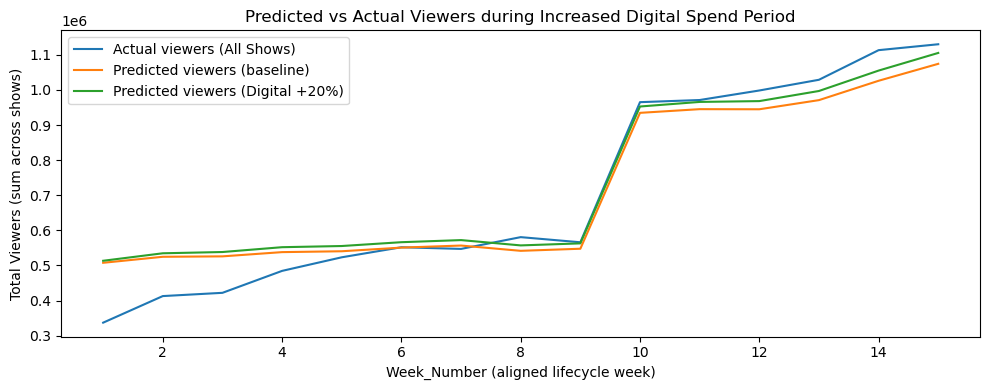

In [52]:
# =========================================================
# Plot: Predicted vs Actual viewers during the increased digital spend period
# (Overall across all shows, aligned by Week_Number)
# =========================================================

overall_by_week = (
    period_df.groupby("Week_Number", as_index=False)
    .agg(
        actual=("actual", "sum"),
        pred_baseline=("pred_baseline", "sum"),
        pred_digital_plus_20=("pred_digital_plus_20", "sum")
    )
    .sort_values("Week_Number")
)

plt.figure(figsize=(10, 4))

# Actual viewers (ground truth)
plt.plot(overall_by_week["Week_Number"], overall_by_week["actual"],
         label="Actual viewers (All Shows)")

# Predicted viewers under baseline spend
plt.plot(overall_by_week["Week_Number"], overall_by_week["pred_baseline"],
         label="Predicted viewers (baseline)")

# Predicted viewers under increased digital spend (+20%)
plt.plot(overall_by_week["Week_Number"], overall_by_week["pred_digital_plus_20"],
         label="Predicted viewers (Digital +20%)")

plt.title("Predicted vs Actual Viewers during Increased Digital Spend Period")
plt.xlabel("Week_Number (aligned lifecycle week)")
plt.ylabel("Total Viewers (sum across shows)")
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
# Count how many unique shows are included in the simulation period for each Week_Number
count_by_week = (
    period_df.groupby("Week_Number")["Show"]
    .nunique()
    .reset_index(name="n_shows")
)

display(count_by_week)

,Week_Number,n_shows
0,1,4
1,2,4
2,3,4
3,4,4
4,5,4
5,6,4
6,7,4
7,8,4
8,9,4
9,10,8


### Simulation Result: Predicted vs Actual Viewers Under Increased Digital Spend

- The simulation suggests a **modest but positive** uplift in predicted viewers when Digital spend is increased by 20%.
- The sharp step-up around **Week 10** is mostly a composition effect: the number of shows included in the aggregated test window rises from **4 to 8**, so total predicted viewers jump even without a sudden change in channel effectiveness.
- Because of that aggregation effect, the chart should be read as directional scenario analysis rather than a clean causal event-study plot.


## 9. Optimization

This section keeps total budget fixed and searches for a more profitable channel mix using the best-performing Model 2 response curves.


In [54]:
# =========================================================
# COMPLETE WORKING CODE:
# Optimization (Model 2 tuned): Reallocate media spend to maximize revenue
# Fixes the shape misalignment by aligning X to final_model2.model.exog_names
# =========================================================

# ---------------------------------------------------------
# REQUIREMENTS / ASSUMES YOU ALREADY HAVE:
# - m2_df: full-series weekly dataframe used for Model 2 (contains Show, Air_Date, spends, controls)
# - m2_test: test split dataframe (we will use as intervention/optimization period)
# - final_model2: fitted statsmodels OLS model for Model 2
# - alpha_net, alpha_cable, alpha_dig: adstock decay parameters for each channel (floats)
# - half_net, half_cable, half_dig, best_slope: tuned Hill params
# - geometric_adstock, hill_saturation: functions
# ---------------------------------------------------------

# -----------------------------
# Helper: build X aligned to fitted model exog (fixes shape mismatch)
# -----------------------------
def build_X_for_model2(df_in: pd.DataFrame, features: list, model) -> pd.DataFrame:
    """
    Builds a design matrix that matches exactly the columns and order
    used when fitting `model` (statsmodels OLS).
    """
    X = pd.get_dummies(df_in[features + ["Show"]], columns=["Show"], drop_first=True)

    # Ensure constant exists
    X = sm.add_constant(X, has_constant="add")

    # Align to the fitted model's exogenous variable names
    exog_names = list(model.model.exog_names)
    X = X.reindex(columns=exog_names, fill_value=0)
    return X

# =========================================================
# 0) Choose intervention period: use m2_test
# =========================================================
key_cols = ["Show", "Air_Date", "Season", "Week_Number", "Episode_Number", "Episode_Type"]

period_df = m2_test.copy()
period_keys = period_df[key_cols].copy()
period_keys["in_period"] = True

# =========================================================
# 1) Full-series simulation frame for carryover
# =========================================================
full_base = m2_df.copy()
full_base = full_base.merge(period_keys, on=key_cols, how="left")
full_base["in_period"] = full_base["in_period"].fillna(False)

# =========================================================
# 2) Baseline prediction in-period + revenue-per-viewer factor
# =========================================================
# Goal:
#   Establish a baseline (current allocation) prediction for the intervention period.
#   This gives us a reference point to compare against any optimized allocation.
#
# Steps:
#   A) Make sure the FULL time series has adstocked media variables (net_ad/cable_ad/dig_ad)
#      - Adstock must be computed on the FULL series per show to preserve carryover effects.
#   B) For the intervention period rows only, apply Hill saturation to the adstock variables.
#   C) Build the model design matrix X aligned to final_model2 and generate baseline predictions.
#   D) Convert predicted viewers to predicted revenue using an estimated revenue-per-viewer factor.

# ---------------------------------------------------------
# A) Ensure baseline adstock exists in full_base (if not, compute it)
# ---------------------------------------------------------
# `need_cols` are the adstocked media variables expected by Model 2.
# If they are missing, we compute them from the raw spend columns.
need_cols = {"net_ad", "cable_ad", "dig_ad"}

if not need_cols.issubset(set(full_base.columns)):
    # Sort ensures correct time order within each show.
    # This is crucial because adstock depends on the previous week's adstock value.
    full_base = full_base.sort_values(["Show", "Air_Date"]).reset_index(drop=True)

    # Compute adstocked spend per show so carryover does not leak across shows.
    # Each channel has its own decay parameter (alpha_*).
    full_base["net_ad"] = full_base.groupby("Show")["Network_TV_Spend"].transform(
        lambda s: geometric_adstock(s.values, alpha_net)
    )
    full_base["cable_ad"] = full_base.groupby("Show")["Cable_TV_Spend"].transform(
        lambda s: geometric_adstock(s.values, alpha_cable)
    )
    full_base["dig_ad"] = full_base.groupby("Show")["Digital_Spend"].transform(
        lambda s: geometric_adstock(s.values, alpha_dig)
    )

# ---------------------------------------------------------
# B) Build baseline saturated media features for the intervention period only
# ---------------------------------------------------------
# We only need saturated features for in-period rows when producing baseline predictions,
# which is faster than computing saturation for the entire dataset.
baseline_period = full_base[full_base["in_period"]].copy()

# Apply Hill saturation to model diminishing returns:
# - half_* controls where the curve hits 50% saturation (channel-specific)
# - best_slope controls steepness (tuned)
baseline_period["net_sat"] = hill_saturation(
    baseline_period["net_ad"].values, half_sat=half_net, slope=best_slope
)
baseline_period["cable_sat"] = hill_saturation(
    baseline_period["cable_ad"].values, half_sat=half_cable, slope=best_slope
)
baseline_period["dig_sat"] = hill_saturation(
    baseline_period["dig_ad"].values, half_sat=half_dig, slope=best_slope
)

# These are the exact features used by Model 2 (media + controls)
features = ["net_sat", "cable_sat", "dig_sat", "Holiday", "LeadIn_Bonus"]

# ---------------------------------------------------------
# C) Build design matrix aligned to the fitted model and predict baseline viewers
# ---------------------------------------------------------
# build_X_for_model2(...) ensures:
# - show dummy columns match the model’s training columns
# - 'const' is included
# - column order matches final_model2.model.exog_names
X_base = build_X_for_model2(baseline_period, features, final_model2)

# Baseline predicted viewers for each row in the intervention period
baseline_period["pred_viewers"] = final_model2.predict(X_base)

# ---------------------------------------------------------
# D) Convert viewers -> revenue using a revenue-per-viewer factor
# ---------------------------------------------------------
# The case assumes revenue is proportional to viewership (fixed $ per viewer).
# We estimate this factor from observed data in the same intervention period:
rev_per_viewer = (
    period_df["Revenue"].astype(float).sum()
    / period_df["True_Viewership"].astype(float).sum()
)

# Predicted revenue per row = predicted viewers * ($ per viewer)
baseline_period["pred_revenue"] = baseline_period["pred_viewers"] * rev_per_viewer

# Total baseline predicted revenue across the entire intervention period
baseline_total_rev = float(baseline_period["pred_revenue"].sum())
print("Baseline predicted revenue (period):", baseline_total_rev)

# =========================================================
# 3) Optimizer: Reallocate in-period total spend per row across channels
#    Grid search over allocation fractions (sum to 1)
# =========================================================
# Goal:
#   Find the channel mix (Network/Cable/Digital share) that maximizes predicted revenue,
#   while keeping the total weekly budget constant during the intervention period.
#
# High-level logic:
#   For each candidate allocation (f_net, f_cable, f_dig):
#     1) Reallocate spend ONLY for rows in the intervention period (in_period=True),
#        keeping each row's total spend constant.
#     2) Recompute adstock for all weeks (full series) per show to preserve carryover.
#     3) Apply saturation + regression model to predict viewers, convert to revenue,
#        and sum revenue over the intervention period.
#     4) Store results and rank allocations by predicted revenue.

def predict_period_revenue_from_full(full_df: pd.DataFrame) -> float:
    """
    Given a full-series dataframe (all weeks) with scenario adstock columns,
    compute the total predicted revenue over the intervention period only.

    Requirements:
      - full_df must include:
          * net_ad, cable_ad, dig_ad (adstocked media variables)
          * in_period flag (True for intervention rows)
      - Uses the same saturation parameters (half_* and best_slope) and
        the fitted Model 2 (final_model2) to generate predictions.
    """
    # Select only the rows within the intervention period (the period we are optimizing)
    period = full_df[full_df["in_period"]].copy()

    # Apply Hill saturation to capture diminishing returns for each channel
    period["net_sat"] = hill_saturation(period["net_ad"].values, half_sat=half_net, slope=best_slope)
    period["cable_sat"] = hill_saturation(period["cable_ad"].values, half_sat=half_cable, slope=best_slope)
    period["dig_sat"] = hill_saturation(period["dig_ad"].values, half_sat=half_dig, slope=best_slope)

    # Build the design matrix aligned to the fitted model's expected columns
    X = build_X_for_model2(period, features, final_model2)

    # Predict viewers, then convert predicted viewers -> predicted revenue
    period["pred_viewers"] = final_model2.predict(X)
    period["pred_revenue"] = period["pred_viewers"] * rev_per_viewer

    # Return total predicted revenue for the intervention period
    return float(period["pred_revenue"].sum())


# ---------------------------------------------------------
# Define the allocation search grid
# ---------------------------------------------------------
# step controls resolution:
# - smaller step (e.g., 0.02) = more precise but slower
# - larger step (e.g., 0.10) = faster but coarser
step = 0.05
fractions = np.arange(0, 1 + 1e-9, step)

results = []

# ---------------------------------------------------------
# Precompute total spend per row to keep budget constant
# ---------------------------------------------------------
# We preserve each row's total marketing budget:
#   total_spend = net + cable + digital
# Then for each allocation we set:
#   net = f_net * total_spend
#   cable = f_cable * total_spend
#   digital = f_dig * total_spend
full_base = full_base.sort_values(["Show", "Air_Date"]).reset_index(drop=True)

row_total_spend = (
    full_base["Network_TV_Spend"].astype(float)
    + full_base["Cable_TV_Spend"].astype(float)
    + full_base["Digital_Spend"].astype(float)
)

# Boolean mask to apply changes only within the intervention period
in_p_mask = full_base["in_period"].values


# ---------------------------------------------------------
# Grid search over allocations (f_net, f_cable, f_dig)
# ---------------------------------------------------------
for f_net in fractions:
    for f_cable in fractions:
        # Ensure fractions sum to 1 by defining digital as the remainder
        f_dig = 1.0 - f_net - f_cable

        # Skip invalid combos where digital would be negative
        if f_dig < -1e-9:
            continue

        # Numerical safety for very small negative values due to floating point
        if f_dig < 0:
            f_dig = 0.0

        # Start from baseline full series and create a scenario copy
        scenario = full_base.copy()

        # ---------------------------------------------------------
        # 3A) Reallocate spends ONLY in-period, keep row total constant
        # ---------------------------------------------------------
        # Initialize scenario spend columns with baseline spends
        scenario["Network_TV_Spend_sim"] = scenario["Network_TV_Spend"].astype(float)
        scenario["Cable_TV_Spend_sim"] = scenario["Cable_TV_Spend"].astype(float)
        scenario["Digital_Spend_sim"] = scenario["Digital_Spend"].astype(float)

        # Overwrite spend values only for in-period rows using the allocation fractions
        scenario.loc[in_p_mask, "Network_TV_Spend_sim"] = row_total_spend[in_p_mask] * f_net
        scenario.loc[in_p_mask, "Cable_TV_Spend_sim"] = row_total_spend[in_p_mask] * f_cable
        scenario.loc[in_p_mask, "Digital_Spend_sim"] = row_total_spend[in_p_mask] * f_dig

        # ---------------------------------------------------------
        # 3B) Recompute adstock on FULL series (per show) for each channel
        # ---------------------------------------------------------
        # Adstock depends on prior weeks, so we must compute it across the full timeline.
        # Grouping by Show prevents carryover from leaking across different shows.
        scenario["net_ad"] = scenario.groupby("Show")["Network_TV_Spend_sim"].transform(
            lambda s: geometric_adstock(s.values, alpha_net)
        )
        scenario["cable_ad"] = scenario.groupby("Show")["Cable_TV_Spend_sim"].transform(
            lambda s: geometric_adstock(s.values, alpha_cable)
        )
        scenario["dig_ad"] = scenario.groupby("Show")["Digital_Spend_sim"].transform(
            lambda s: geometric_adstock(s.values, alpha_dig)
        )

        # ---------------------------------------------------------
        # 3C) Predict total revenue in the intervention period
        # ---------------------------------------------------------
        total_rev = predict_period_revenue_from_full(scenario)

        # Store results for ranking
        results.append({
            "frac_net": float(f_net),
            "frac_cable": float(f_cable),
            "frac_dig": float(f_dig),
            "pred_revenue": total_rev,
        })
# =========================================================
# 4) Report best allocation + lift
# =========================================================
# At this point, `results` contains one row per tested allocation:
#   - frac_net, frac_cable, frac_dig: the spend split across channels (sums to 1)
#   - pred_revenue: total predicted revenue over the intervention period under that allocation
#
# Next, we:
#   1) Convert results into a DataFrame
#   2) Sort by predicted revenue to find the best allocation
#   3) Compute the revenue lift relative to the baseline allocation
#   4) Print and display the top-performing allocations

# Convert list of dictionaries into a DataFrame and rank allocations by predicted revenue
res_df = (
    pd.DataFrame(results)
      .sort_values("pred_revenue", ascending=False)  # best allocation first
      .reset_index(drop=True)                        # clean index for readability
)

# Select the top (best) allocation
best = res_df.iloc[0]

# Extract the predicted revenue for the best allocation
best_total_rev = float(best["pred_revenue"])

# Compute the absolute revenue lift vs. baseline
# baseline_total_rev was computed earlier using the original spend allocation
lift = best_total_rev - baseline_total_rev

# Compute the percentage lift vs. baseline (avoid divide-by-zero)
lift_pct = lift / baseline_total_rev if baseline_total_rev != 0 else np.nan

# Print the best allocation mix and its predicted revenue
print("\n=== BEST ALLOCATION (within period, constant total spend) ===")
print(best.to_string())

# Print lift metrics for business interpretation
print("\nPredicted revenue lift vs baseline:")
print("Lift ($):", lift)
print("Lift (%):", lift_pct)

# Show the top 10 allocations to understand the neighborhood of the optimum
# (useful to see whether the best result is stable or sensitive to small changes)
display(res_df.head(10))

# =========================================================
# 5) Build a recommended scenario_period table for plotting/analysis
#     using the best fractions
# =========================================================
best_net = float(best["frac_net"])
best_cable = float(best["frac_cable"])
best_dig = float(best["frac_dig"])

scenario_best = full_base.copy()
scenario_best["Network_TV_Spend_sim"] = scenario_best["Network_TV_Spend"].astype(float)
scenario_best["Cable_TV_Spend_sim"] = scenario_best["Cable_TV_Spend"].astype(float)
scenario_best["Digital_Spend_sim"] = scenario_best["Digital_Spend"].astype(float)

scenario_best.loc[in_p_mask, "Network_TV_Spend_sim"] = row_total_spend[in_p_mask] * best_net
scenario_best.loc[in_p_mask, "Cable_TV_Spend_sim"] = row_total_spend[in_p_mask] * best_cable
scenario_best.loc[in_p_mask, "Digital_Spend_sim"] = row_total_spend[in_p_mask] * best_dig

scenario_best["net_ad"] = scenario_best.groupby("Show")["Network_TV_Spend_sim"].transform(
    lambda s: geometric_adstock(s.values, alpha_net)
)
scenario_best["cable_ad"] = scenario_best.groupby("Show")["Cable_TV_Spend_sim"].transform(
    lambda s: geometric_adstock(s.values, alpha_cable)
)
scenario_best["dig_ad"] = scenario_best.groupby("Show")["Digital_Spend_sim"].transform(
    lambda s: geometric_adstock(s.values, alpha_dig)
)

best_period = scenario_best[scenario_best["in_period"]].copy()
best_period["net_sat"] = hill_saturation(best_period["net_ad"].values, half_sat=half_net, slope=best_slope)
best_period["cable_sat"] = hill_saturation(best_period["cable_ad"].values, half_sat=half_cable, slope=best_slope)
best_period["dig_sat"] = hill_saturation(best_period["dig_ad"].values, half_sat=half_dig, slope=best_slope)

X_best = build_X_for_model2(best_period, features, final_model2)
best_period["pred_viewers_best_alloc"] = final_model2.predict(X_best)
best_period["pred_revenue_best_alloc"] = best_period["pred_viewers_best_alloc"] * rev_per_viewer


Baseline predicted revenue (period): 7516606.586252112

=== BEST ALLOCATION (within period, constant total spend) ===
frac_net               0.40
frac_cable             0.60
frac_dig               0.00
pred_revenue   8,166,795.98

Predicted revenue lift vs baseline:
Lift ($): 650189.3895071968
Lift (%): 0.08650038844608343


,frac_net,frac_cable,frac_dig,pred_revenue
0,0.40,0.60,0.00,"8,166,795.98"
1,0.35,0.65,0.00,"8,165,076.67"
2,0.45,0.55,0.00,"8,142,308.35"
3,0.30,0.70,0.00,"8,138,066.74"
4,0.35,0.60,0.05,"8,094,646.97"
5,0.50,0.50,0.00,"8,091,138.93"
6,0.25,0.75,0.00,"8,087,517.33"
7,0.40,0.55,0.05,"8,083,307.49"
8,0.30,0.65,0.05,"8,079,631.33"
9,0.45,0.50,0.05,"8,044,666.92"


### Optimization Summary

- The best tested allocation for the intervention period is **40% Network TV, 60% Cable TV, and 0% Digital**.
- Under that allocation, predicted revenue increases from about **$7.52M** to **$8.17M**, for an estimated lift of roughly **$650K (+8.7%)**.
- The top-performing allocations consistently shift budget toward TV, which is consistent with the MMM finding that TV channels have stronger marginal returns than Digital in this dataset.


## 10. Overall Conclusion

This case study shows an end-to-end workflow from Silver-layer data quality assessment to Gold-layer reporting and MMM-based business recommendation. After cleaning light missingness, removing duplicates, and aggregating to a weekly Gold grain, the modeling results consistently show that **Cable TV** is the strongest driver of viewership lift, followed by **Network TV**, with **Digital** still positive but less efficient at the margin.

The most realistic specification in this notebook is the adstock-plus-saturation MMM, which performs best out of sample and supports both scenario analysis and budget optimization. Based on that model, reallocating spend toward TV channels is expected to improve revenue under a fixed budget constraint.
